# Loading + preprocessing

In [1]:
import subprocess, sys

packages_to_install = [
    "numpy==1.26.4",          # Pin numpy FIRST and explicitly
    "pandas",
    "pmdarima",
    "arch",
    "tbats",
    "neuralprophet",
    "prophet",
    "Pillow==9.5.0",
]

# Install numpy alone first to establish the ABI baseline
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "numpy==1.26.4", "--force-reinstall", "-q"])

# Then install the rest (they'll compile/link against the pinned numpy)
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       *packages_to_install[1:], "-q"])

print("✅ Installation complete — NOW RESTART THE RUNTIME")
print("Runtime → Restart runtime  (do NOT re-run this cell after restart)")

✅ Installation complete — NOW RESTART THE RUNTIME
Runtime → Restart runtime  (do NOT re-run this cell after restart)


In [1]:
# ---- CELL 1: Google Drive Setup (Colab only) ----
from google.colab import drive
drive.mount('/content/drive')
import os
PROJECT_ROOT = '/content/drive/MyDrive/NIFTY50_Forecast'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Project root : {PROJECT_ROOT}")
print(f"Data folder : {DATA_DIR}")

Mounted at /content/drive
Project root : /content/drive/MyDrive/NIFTY50_Forecast
Data folder : /content/drive/MyDrive/NIFTY50_Forecast/data


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle, os
import yfinance as yf # Added yfinance import

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm # Added this import for 'pm'
from statsmodels.tsa.arima.model import ARIMA # Added this import for 'ARIMA'
from statsmodels.tsa.statespace.sarimax import SARIMAX # Added this import for 'SARIMAX'
from arch import arch_model
from tbats import TBATS
from prophet import Prophet
from neuralprophet import NeuralProphet
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score # Added this import
)
from sklearn.ensemble import RandomForestRegressor # Added this import
from sklearn.inspection import permutation_importance # Added this import
from scipy import stats
from sklearn.preprocessing import StandardScaler # Fixed: Moved to new line

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


In [3]:
from sklearn.metrics import (
    r2_score # Added this import
)

In [4]:
from sklearn.ensemble import RandomForestRegressor # Added this import
from sklearn.inspection import permutation_importance # Added this import

In [5]:
# ---- CELL 4: Data Download ----
TICKERS = {
'nifty50' : '^NSEI',
'niftybank': '^NSEBANK',
'gold' : 'GC=F',
'usdinr' : 'INR=X',
'crude' : 'CL=F',
}
START, END = "2009-01-01", "2024-12-31"
def dl(ticker):
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df
raw = dl('^NSEI')
df_main = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
for name, tkr in TICKERS.items():
    if name == 'nifty50':
        continue
    df_main[f'macro_{name}'] = dl(tkr)['Close']
df_main.dropna(inplace=True)
df_main['log_close'] = np.log(df_main['Close'])
df_main['log_diff'] = df_main['log_close'].diff()
print(f"Shape: {df_main.shape} | {df_main.index[0].date()} → {df_main.index[-1].date()}")

Shape: (3807, 11) | 2009-01-02 → 2024-12-30


Dataset one and dataset two

In [6]:
import pandas as pd
# ---- CELL 5: IMPROVED Feature Engineering ----
# Key change: Added RSI, MACD, Bollinger Bands, ATR, calendar features,
# more lags, return windows — these existed in EDA but were NEVER used
# in preprocessing. This is the single biggest improvement.
def build_features(df):
    d = df.copy()
    # --- Lagged Prices ---
    for lag in [1, 2, 3, 5, 10, 21]:
        d[f'lag_{lag}'] = d['Close'].shift(lag)
    # --- Moving Averages ---
    d['sma_5'] = d['Close'].shift(1).rolling(5).mean()
    d['sma_10'] = d['Close'].shift(1).rolling(10).mean()
    d['sma_20'] = d['Close'].shift(1).rolling(20).mean()
    d['sma_50'] = d['Close'].shift(1).rolling(50).mean()
    d['ema_10'] = d['Close'].shift(1).ewm(span=10, adjust=False).mean()
    d['ema_21'] = d['Close'].shift(1).ewm(span=21, adjust=False).mean()
    # --- MA Ratio Crossover Signals ---
    d['sma_5_20_ratio'] = d['sma_5'] / (d['sma_20'] + 1e-10)
    d['sma_10_50_ratio'] = d['sma_10'] / (d['sma_50'] + 1e-10)
    d['ema_sma_ratio'] = d['ema_10'] / (d['sma_10'] + 1e-10)
    # --- Momentum ---
    d['momentum_5'] = d['Close'].shift(1) - d['Close'].shift(6)
    d['momentum_10'] = d['Close'].shift(1) - d['Close'].shift(11)
    d['momentum_21'] = d['Close'].shift(1) - d['Close'].shift(22)
    # --- Log Returns ---
    d['return_1d'] = d['log_diff'].shift(1)
    d['return_5d'] = d['log_diff'].shift(1).rolling(5).sum()
    d['return_10d'] = d['log_diff'].shift(1).rolling(10).sum()
    # --- Volatility ---
    d['volatility_10'] = d['log_diff'].shift(1).rolling(10).std()
    d['volatility_20'] = d['log_diff'].shift(1).rolling(20).std()
    # --- RSI (14) — shifted to avoid leakage ---
    close_s = d['Close'].shift(1)
    delta = close_s.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    d['rsi_14'] = 100 - (100 / (1 + rs))
    # --- Bollinger Bands ---
    bb_mid = d['Close'].shift(1).rolling(20).mean()
    bb_std = d['Close'].shift(1).rolling(20).std()
    d['bb_upper'] = bb_mid + 2 * bb_std
    d['bb_lower'] = bb_mid - 2 * bb_std
    d['bb_width'] = (d['bb_upper'] - d['bb_lower']) / (bb_mid + 1e-10)
    d['bb_pct'] = (d['Close'].shift(1) - d['bb_lower']) / \
    (d['bb_upper'] - d['bb_lower'] + 1e-10)
    # --- MACD ---
    ema_12 = d['Close'].shift(1).ewm(span=12, adjust=False).mean()
    ema_26 = d['Close'].shift(1).ewm(span=26, adjust=False).mean()
    d['macd'] = ema_12 - ema_26
    d['macd_sig'] = d['macd'].ewm(span=9, adjust=False).mean()
    d['macd_hist']= d['macd'] - d['macd_sig']
    # --- ATR (Average True Range as % of Close) ---
    high_s = d['High'].shift(1)
    low_s = d['Low'].shift(1)
    close_prev = d['Close'].shift(2)
    tr = pd.concat([
    high_s - low_s,
    (high_s - close_prev).abs(),
    (low_s - close_prev).abs()
    ], axis=1).max(axis=1)
    d['atr_14'] = tr.rolling(14).mean() / (d['Close'].shift(1) + 1e-10)
    # --- Calendar (market timing effects) ---
    d['day_of_week'] = d.index.dayofweek
    d['month'] = d.index.month
    # 0=Mon, 4=Fri
    d['quarter'] = d.index.quarter
    d.dropna(inplace=True)
    return d
df_d1 = df_main.loc[:'2019-01-31'].copy()
df_d2 = df_main.copy()
df_d1 = build_features(df_d1)
df_d2 = build_features(df_d2)
print(f"D1: {df_d1.shape} | D2: {df_d2.shape}")

D1: (2345, 46) | D2: (3757, 46)


In [7]:
# ---- CELL 6: Feature Selection via Permutation Importance ----
MACRO_COLS = [c for c in df_d2.columns if c.startswith('macro_')]
TECH_FEATS = [
'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'lag_21',
'sma_5', 'sma_10', 'sma_20', 'sma_50', 'ema_10', 'ema_21',
'sma_5_20_ratio', 'sma_10_50_ratio', 'ema_sma_ratio',
'momentum_5', 'momentum_10', 'momentum_21',
'return_1d', 'return_5d', 'return_10d',
'volatility_10', 'volatility_20',
'rsi_14', 'bb_width', 'bb_pct',
'macd', 'macd_sig', 'macd_hist',
'atr_14', 'day_of_week', 'month', 'quarter',
]
ALL_FEATS = TECH_FEATS + MACRO_COLS
split_idx = int(len(df_d2) * 0.8)
X_sig = df_d2[ALL_FEATS].iloc[:split_idx]
y_sig = df_d2['Close'].iloc[:split_idx]
rf_sig = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_sig.fit(X_sig, y_sig)
perm = permutation_importance(rf_sig, X_sig, y_sig,
n_repeats=5, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({'Feature': ALL_FEATS, 'Importance': perm.importances_mean})
imp_df = imp_df.sort_values('Importance', ascending=False)
print(imp_df.to_string(index=False))
# Keep features with positive importance
FINAL_FEATS = imp_df[imp_df['Importance'] > 0]['Feature'].tolist()
SIGNIFICANT_MACROS = [f for f in FINAL_FEATS if f.startswith('macro_')]
print(f"\nFinal feature set ({len(FINAL_FEATS)}): {FINAL_FEATS}")
print(f"Significant macros: {SIGNIFICANT_MACROS}")

        Feature  Importance
          lag_1    1.250103
macro_niftybank    0.010630
          sma_5    0.005095
         sma_50    0.004072
         ema_10    0.002698
         ema_21    0.002587
          lag_2    0.002460
         sma_20    0.001337
         sma_10    0.000914
          lag_3    0.000644
         lag_10    0.000360
          lag_5    0.000286
    macro_crude    0.000074
   macro_usdinr    0.000063
     macro_gold    0.000021
  volatility_20    0.000021
         atr_14    0.000020
         lag_21    0.000020
  ema_sma_ratio    0.000020
       bb_width    0.000018
       macd_sig    0.000017
      return_1d    0.000017
    momentum_21    0.000016
  volatility_10    0.000015
          month    0.000015
           macd    0.000014
      macd_hist    0.000014
         rsi_14    0.000014
 sma_5_20_ratio    0.000012
      return_5d    0.000012
sma_10_50_ratio    0.000011
         bb_pct    0.000011
    momentum_10    0.000011
     momentum_5    0.000010
     return_10d    0

In [8]:
# ---- CELL 7: Train/Test Split & Scaling ----
LOOKBACK = 30 # Increased from 15 — LSTM needs more context for stock regimes
LSTM_LOOKBACK = 60 # Set LSTM specific lookback to 60 days
def split_and_scale(df, feature_cols, target='Close', test_ratio=0.2):
    split = int(len(df) * (1 - test_ratio))
    tr, te = df.iloc[:split].copy(), df.iloc[split:].copy()
    scX = StandardScaler()
    scY = StandardScaler()
    X_tr = scX.fit_transform(tr[feature_cols])
    X_te = scX.transform(te[feature_cols])
    y_tr = scY.fit_transform(tr[[target]]).ravel()
    y_te = scY.transform(te[[target]]).ravel()
    # transform only — no fit
    return X_tr, X_te, y_tr, y_te, scX, scY, tr, te
X_tr1, X_te1, y_tr1, y_te1, scX1, scY1, tr1, te1 = split_and_scale(df_d1, FINAL_FEATS)
X_tr2, X_te2, y_tr2, y_te2, scX2, scY2, tr2, te2 = split_and_scale(df_d2, FINAL_FEATS)
print(f"D1 → Train: {X_tr1.shape} | Test: {X_te1.shape}")
print(f"D2 → Train: {X_tr2.shape} | Test: {X_te2.shape}")

D1 → Train: (1876, 37) | Test: (469, 37)
D2 → Train: (3005, 37) | Test: (752, 37)


In [9]:
# ---- CELL 8: LSTM Sequences ----
def make_sequences(X, y, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)
def make_test_sequences(X_tr, X_te, y_te, lookback=LOOKBACK):
    X_bridge = np.concatenate([X_tr[-lookback:], X_te], axis=0)
    Xs, ys = [], []
    for i in range(lookback, len(X_bridge)):
        Xs.append(X_bridge[i-lookback:i])
        ys.append(y_te[i - lookback])
    return np.array(Xs), np.array(ys)
Xsl_tr1, ysl_tr1 = make_sequences(X_tr1, y_tr1)
Xsl_te1, ysl_te1 = make_test_sequences(X_tr1, X_te1, y_te1)
Xsl_tr2, ysl_tr2 = make_sequences(X_tr2, y_tr2)
Xsl_te2, ysl_te2 = make_test_sequences(X_tr2, X_te2, y_te2)
print(f"LSTM D1 train: {Xsl_tr1.shape} | test: {Xsl_te1.shape}")
print(f"LSTM D2 train: {Xsl_tr2.shape} | test: {Xsl_te2.shape}")

LSTM D1 train: (1846, 30, 37) | test: (469, 30, 37)
LSTM D2 train: (2975, 30, 37) | test: (752, 30, 37)


In [10]:
# ---- CELL 9: Evaluation Utilities ----
results = {}

def evaluate(y_true_sc, y_pred_sc, scaler_y, label):
    yt = scaler_y.inverse_transform(y_true_sc.reshape(-1, 1)).ravel()
    yp = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    mape = np.mean(np.abs((yt - yp) / yt)) * 100
    r2 = r2_score(yt, yp)
    print(f"{label:<42s} RMSE={rmse:8.1f} | MAE={mae:7.1f} | MAPE={mape:5.2f}% | R²={r2:.4f}")
    return dict(label=label, RMSE=rmse, MAE=mae, MAPE=mape, R2=r2, y_true=yt, y_pred=yp)

def evaluate_raw(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{label:<42s} RMSE={rmse:8.1f} | MAE={mae:7.1f} | MAPE={mape:5.2f}% | R²={r2:.4f}")
    return dict(label=label, RMSE=rmse, MAE=mae, MAPE=mape, R2=r2, y_true=y_true, y_pred=y_pred)
# --- Baseline: naive last-known-value ---
for tag, te in [('D1', te1), ('D2', te2)]:
    y_true = te['Close'].values
    y_pred = te['Close'].shift(1).bfill().values
    results[f'baseline_{tag}'] = evaluate_raw(y_true, y_pred, f'Baseline {tag}')

Baseline D1                                RMSE=    74.8 | MAE=   56.7 | MAPE= 0.55% | R²=0.9869
Baseline D2                                RMSE=   176.3 | MAE=  128.7 | MAPE= 0.67% | R²=0.9962


### New Baseline: 'Always Up' Prediction

To explicitly test if our models are just predicting 'up' all the time, we introduce a new baseline that always predicts a tiny increase from the previous day's closing price. This helps validate if our models are truly learning directional movements rather than simply riding a market trend.

In [47]:
# --- Baseline: naive 'always up' prediction (a small 0.1% increase) ---
for tag, te in [('D1', te1), ('D2', te2)]:
    y_true = te['Close'].values
    # Predict a 0.1% increase from the previous day's ACTUAL close
    y_pred = (te['Close'].shift(1) * 1.001).bfill().values
    results[f'always_up_baseline_{tag}'] = evaluate_raw(y_true, y_pred, f'Always Up Baseline {tag}')

print("✅ Added 'Always Up' baselines to results.")

Always Up Baseline D1                      RMSE=    75.0 | MAE=   56.5 | MAPE= 0.55% | R²=0.9868
Always Up Baseline D2                      RMSE=   176.6 | MAE=  128.4 | MAPE= 0.66% | R²=0.9961
✅ Added 'Always Up' baselines to results.


### Re-evaluating Directional Accuracy with 'Always Up' Baseline

Now we re-run the directional accuracy comparison, including the new 'Always Up' baseline. Any model that significantly outperforms this baseline is genuinely capturing predictive signals for market direction. The confusion matrices below will further elaborate on the breakdown of these predictions.

In [48]:
# ── DIRECTIONAL ACCURACY — ALL MODELS (with new baseline) ──────────────────
# This cell works on your existing `results` dict.
# Every entry in results has 'y_true' and 'y_pred' as price-level arrays.

print("=" * 65)
print(f"{'Model':<42s} {'Dir Acc':>8}  {'Correct':>7}  {'Total':>6}")
print("=" * 65)

# Define display order — edit keys to match what you have in your results dict
ordered_keys = [
    # Baselines
    'baseline_D1', 'always_up_baseline_D1', 'baseline_D2', 'always_up_baseline_D2',
    # SARIMA
    'sarima_D1',   'sarima_D2',
    # NeuralProphet (original)
    'np_D1',       'np_D2',
    # NeuralProphet Walk-Forward
    'np_wf_D1',    'np_wf_D2',
    # LSTM (original bidirectional)
    'lstm_D1',     'lstm_D2',
    # Improved LSTM single-shot
    'lstm_imp_D1', 'lstm_imp_D2',
    # Improved LSTM walk-forward
    'lstm_wf_D1',  'lstm_wf_D2',
    # Random Forest
    'rf_D1', 'rf_D2'
]

dir_acc_results = {}

for key in ordered_keys:
    if key not in results:
        # Some models might not be in results yet, due to selective running.
        # This ensures the script doesn't break but indicates missing data.
        print(f"  [skipped — not in results: {key}]")
        continue
    r = results[key]
    acc, correct, total = directional_accuracy(r['y_true'], r['y_pred'])
    dir_acc_results[key] = acc
    flag = " ◀ STRONG" if acc >= 55 else (" ◀ BASELINE" if 'baseline' in key else "")
    print(f"  {r['label']:<42s} {acc:>6.2f}%  {correct:>7}  {total:>6}{flag}")

print("=" * 65)
print("\nBaseline always predicts zero change → its directional accuracy")
print("reflects only the natural market up-bias, NOT learned signals.")
print("Any model significantly above baseline here is genuinely learning direction.")


Model                                       Dir Acc  Correct   Total
  Baseline D1                                  0.21%        1     468 ◀ BASELINE
  Always Up Baseline D1                       54.49%      255     468 ◀ BASELINE
  Baseline D2                                  0.13%        1     751 ◀ BASELINE
  Always Up Baseline D2                       53.66%      403     751 ◀ BASELINE
  SARIMA D1                                   52.14%      244     468
  SARIMA D2                                   50.07%      376     751
  NeuralProphet D1                            51.50%      241     468
  NeuralProphet D2                            49.00%      368     751
  [skipped — not in results: np_wf_D1]
  [skipped — not in results: np_wf_D2]
  LSTM D1                                     45.51%      213     468
  LSTM D2                                     46.21%      347     751
  LSTM Improved (returns) D1                  55.56%      260     468 ◀ STRONG
  LSTM Improved (returns) D2  

### Re-evaluating Confusion Matrices with 'Always Up' Baseline

We now regenerate the confusion matrices. This detailed view is crucial for identifying if a model consistently predicts 'up' (or 'down'), regardless of the actual market movement. If a model tends to always predict 'up', you would see the majority of its predictions concentrated in the 'Predicted Up (+1)' column, even for days when the actual movement was 'Down (-1)'.

In [49]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

print("=" * 70)
print(" CONFUSION MATRICES FOR DIRECTIONAL PREDICTIONS (with new baseline)")
print("=" * 70)

# Define the labels for the confusion matrix (negative for down, positive for up)
LABELS = [-1, 1] # Assuming we primarily care about up/down

for key, r in results.items():
    # Only display confusion matrices for the keys we're explicitly comparing,
    # including the new baselines and the Random Forest models.
    if key not in ordered_keys:
        continue

    if 'y_true' not in r or 'y_pred' not in r:
        print(f"Skipping {r.get('label', key)}: missing y_true or y_pred")
        continue

    y_true = np.array(r['y_true'])
    y_pred = np.array(r['y_pred'])

    # Calculate actual and predicted directions, similar to directional_accuracy
    actual_dir_raw = np.sign(y_true[1:] - y_true[:-1])
    pred_dir_raw   = np.sign(y_pred[1:] - y_true[:-1])

    # Filter out zero changes from actual movements to focus on clear up/down classifications
    non_zero_mask = (actual_dir_raw != 0)
    actual_dir = actual_dir_raw[non_zero_mask]
    pred_dir   = pred_dir_raw[non_zero_mask]

    # For models that output 0 (no change), we treat it as 'down' (-1) prediction.
    pred_dir_processed = np.where(pred_dir == 0, -1, pred_dir)

    # Generate confusion matrix
    if len(actual_dir) > 0 and len(pred_dir_processed) > 0:
        cm = confusion_matrix(actual_dir, pred_dir_processed, labels=LABELS)
        # Display results
        print(f"\n--- Model: {r['label']} ---")
        print("Confusion Matrix:")
        cm_df = pd.DataFrame(cm, index=['Actual Down (-1)', 'Actual Up (+1)'], columns=['Predicted Down (-1)', 'Predicted Up (+1)'])
        print(cm_df.to_string())
    else:
        print(f"\n--- Model: {r['label']} ---")
        print("Not enough data to compute confusion matrix after filtering zero changes.")

print("=" * 70)


 CONFUSION MATRICES FOR DIRECTIONAL PREDICTIONS (with new baseline)

--- Model: Baseline D1 ---
Confusion Matrix:
                  Predicted Down (-1)  Predicted Up (+1)
Actual Down (-1)                  212                  0
Actual Up (+1)                    255                  0

--- Model: Baseline D2 ---
Confusion Matrix:
                  Predicted Down (-1)  Predicted Up (+1)
Actual Down (-1)                  347                  0
Actual Up (+1)                    403                  0

--- Model: SARIMA D1 ---
Confusion Matrix:
                  Predicted Down (-1)  Predicted Up (+1)
Actual Down (-1)                   90                122
Actual Up (+1)                    101                154

--- Model: SARIMA D2 ---
Confusion Matrix:
                  Predicted Down (-1)  Predicted Up (+1)
Actual Down (-1)                  156                191
Actual Up (+1)                    183                220

--- Model: Random Forest D1 ---
Confusion Matrix:
                 

# ARIMA

In [11]:
#---- CELL 11: SARIMA (auto-selects seasonal params — no more hardcoding) ----
# Old code used hardcoded (1,1,1)(1,1,0,5) with no validation
def run_sarima(tr_df, te_df, label):
    tr_log = np.log(tr_df['Close'])
    te_log = np.log(te_df['Close'])

    # m=5: weekly seasonality (5 trading days)
    auto = pm.auto_arima(
        tr_log, d=1, D=1, m=5,
        seasonal=True, stepwise=True,
        suppress_warnings=True, error_action='ignore',
        max_p=3, max_q=3, max_P=2, max_Q=2,
        information_criterion='aicc'
    )
    print(f"  {label} → best order: {auto.order}  seasonal: {auto.seasonal_order}")

    fitted = SARIMAX(
        tr_log, order=auto.order, seasonal_order=auto.seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)

    preds_log = []
    for obs in te_log:
        preds_log.append(fitted.forecast(1).iloc[0])
        fitted = fitted.extend([obs])

    y_true = te_df['Close'].values
    y_pred = np.exp(np.array(preds_log))
    return evaluate_raw(y_true, y_pred, label)

results['sarima_D1'] = run_sarima(tr1, te1, 'SARIMA D1')
results['sarima_D2'] = run_sarima(tr2, te2, 'SARIMA D2')



WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)

  self._init_dates(dates, freq)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)

  self._init_dates(dates, freq)



  SARIMA D1 → best order: (2, 1, 0)  seasonal: (2, 1, 0, 5)


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  warnings.warn("Maximum Likelihood optimization failed to "

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(

  return get_prediction_index(

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(

  return get_prediction_index(



SARIMA D1                                  RMSE=    84.5 | MAE=   63.6 | MAPE= 0.61% | R²=0.9833


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)

  self._init_dates(dates, freq)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)

  self._init_dates(dates, freq)



  SARIMA D2 → best order: (2, 1, 0)  seasonal: (2, 1, 0, 5)


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  warnings.warn("Maximum Likelihood optimization failed to "

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(

  return get_prediction_index(

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(

  return get_prediction_index(



SARIMA D2                                  RMSE=   207.7 | MAE=  153.5 | MAPE= 0.79% | R²=0.9947


In [12]:
from sklearn.linear_model import LinearRegression

# --- CELL 12: Multiple Linear Regression (MR) ----

def run_mr(X_tr, y_tr, X_te, y_te, scY, label):
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return evaluate(y_te, preds, scY, label), model

results['mr_D1'], mr_model_d1 = run_mr(X_tr1, y_tr1, X_te1, y_te1, scY1, 'Linear Regression D1')
results['mr_D2'], mr_model_d2 = run_mr(X_tr2, y_tr2, X_te2, y_te2, scY2, 'Linear Regression D2')

Linear Regression D1                       RMSE=   102.0 | MAE=   82.9 | MAPE= 0.80% | R²=0.9757
Linear Regression D2                       RMSE=   188.4 | MAE=  141.2 | MAPE= 0.72% | R²=0.9956


# Prophet (scaled prices)

In [14]:
# –– CELL 13: Prophet (fixed macro bug + multiplicative seasonality) ––

# BUG FIXED: original te_p had no macro_cols but future df tried to access them

# IMPROVEMENT: multiplicative mode better for price-scale data

def run_prophet(tr_df, te_df, macro_cols, label):
    tr_p = tr_df[['Close'] + macro_cols].reset_index().rename(
        columns={'Date': 'ds', 'Close': 'y'})
    te_p = te_df[['Close'] + macro_cols].reset_index().rename(   # FIX: include macros
        columns={'Date': 'ds', 'Close': 'y'})

    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.1,          # up from 0.05 — more flexibility
        seasonality_prior_scale=10,
        seasonality_mode='multiplicative',    # better for index levels (not returns)
    )
    for col in macro_cols:
        m.add_regressor(col)
    m.fit(tr_p)

    future   = te_p[['ds'] + macro_cols]     # FIX: now has the columns
    fc       = m.predict(future)
    y_true   = te_df['Close'].values
    y_pred   = fc['yhat'].values
    return evaluate_raw(y_true, y_pred, label)

results['prophet_D1'] = run_prophet(tr1, te1, SIGNIFICANT_MACROS, 'Prophet D1')
results['prophet_D2'] = run_prophet(tr2, te2, SIGNIFICANT_MACROS, 'Prophet D2')

Prophet D1                                 RMSE=   297.9 | MAE=  224.0 | MAPE= 2.11% | R²=0.7925
Prophet D2                                 RMSE=  2209.1 | MAE= 2005.5 | MAPE= 9.96% | R²=0.3962


# Initial LSTM (scaled prices)

In [15]:
# –– CELL 16: LSTM (Bidirectional + BatchNorm + Huber + ReduceLR) ––

# IMPROVEMENTS:

# - Bidirectional LSTM: learns forward + backward patterns

# - BatchNormalization: stabilises training, faster convergence

# - Huber loss: robust to price-spike outliers (COVID crash etc.)

# - ReduceLROnPlateau: adaptive LR instead of fixed

# - LOOKBACK=30 (was 15): captures 6 full trading weeks of context

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Bidirectional, Dropout,
Dense, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def build_lstm(n_features, lookback):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True,
                           input_shape=(lookback, n_features))),
        BatchNormalization(),
        Dropout(0.2),

        Bidirectional(LSTM(64, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.15),

        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.1),

        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber'    # Huber is robust to outliers vs MSE
    )
    return model

def run_lstm(Xsl_tr, ysl_tr, Xsl_te, ysl_te, scY, label):
    n_feats  = Xsl_tr.shape[2]
    lookback = Xsl_tr.shape[1]
    model    = build_lstm(n_feats, lookback)

    es  = EarlyStopping(monitor='val_loss', patience=20,
                        restore_best_weights=True)
    rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                             patience=10, min_lr=1e-5, verbose=0)

    model.fit(
        Xsl_tr, ysl_tr,
        validation_split=0.1,
        epochs=150,
        batch_size=64,
        callbacks=[es, rlr],
        verbose=0
    )
    preds = model.predict(Xsl_te, verbose=0).ravel()
    return evaluate(ysl_te, preds, scY, label), model

results['lstm_D1'], lstm_model_d1 = run_lstm(
Xsl_tr1, ysl_tr1, Xsl_te1, ysl_te1, scY1, 'LSTM D1')
results['lstm_D2'], lstm_model_d2 = run_lstm(
Xsl_tr2, ysl_tr2, Xsl_te2, ysl_te2, scY2, 'LSTM D2')

LSTM D1                                    RMSE=  1745.7 | MAE= 1608.8 | MAPE=15.26% | R²=-6.1281
LSTM D2                                    RMSE=  7955.5 | MAE= 7481.6 | MAPE=36.79% | R²=-6.8306


# Initial Neural Prophet (scaled prices)

In [16]:
# –– CELL 15: NeuralProphet (FIXED: data leakage removed) ––

# BUG FIXED: original fit NeuralProphet on pd.concat([tr_np, te_np]) — the model

# saw test prices during training. Now fits on train only with a held-out val set.

def run_neuralprophet(tr_df, te_df, label):
    tr_np = tr_df[['Close']].reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})
    te_np = te_df[['Close']].reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})

    m = NeuralProphet(
        n_lags=LOOKBACK,
        n_forecasts=1,
        weekly_seasonality=True,
        yearly_seasonality=True,
        learning_rate=0.003,
        epochs=100,
        batch_size=64,
    )

    # FIX: fit on train only; use last 10% of train as validation
    val_split = int(len(tr_np) * 0.9)
    tr_sub    = tr_np.iloc[:val_split].reset_index(drop=True)
    val_sub   = tr_np.iloc[val_split:].reset_index(drop=True)

    m.fit(tr_sub, validation_df=val_sub, freq='B')

    # Predict on test: provide full train history so autoregressive lags work
    full_df = pd.concat([tr_np, te_np]).reset_index(drop=True)
    future  = m.make_future_dataframe(full_df, n_historic_predictions=len(te_np))
    fc      = m.predict(future)
    fc      = fc[fc['ds'].isin(te_df.index)]

    y_true = te_df['Close'].values[:len(fc)]
    y_pred = fc['yhat1'].values
    return evaluate_raw(y_true, y_pred, label)

results['np_D1'] = run_neuralprophet(tr1, te1, 'NeuralProphet D1')
results['np_D2'] = run_neuralprophet(tr2, te2, 'NeuralProphet D2')

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 91.765% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 91.765% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
INFO - (NP.data.processing._handle_missing_data) - Added 166 missing dates.
INFO:NP.data.processing:Added 166 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 166 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 166 NaN values in column y were auto-imputed.
INFO:NP.data.processing:166 NaN values in column y were auto-imputed.
INFO - (NP.data.processing._handle_missing_data) - Added 18 missing dates.
INFO:NP.data.processing:Added 18 missing dates.
WARNING - (NP.data.processing._

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 91.403% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 91.403% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 90.805% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 90.805% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 90.805% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 90.805% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is

Predicting: 46it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


NeuralProphet D2                           RMSE=   457.3 | MAE=  358.7 | MAPE= 1.86% | R²=0.9741


# Results (initial)

In [17]:
# –– CELL 17: Results Summary ––

rows = []
for key, r in results.items():
    rows.append({
        'Model'  : r['label'],
        'RMSE'   : round(r['RMSE'], 2),
        'MAE'    : round(r['MAE'], 2),
        'MAPE(%)': round(r['MAPE'], 3),
        'R²'     : round(r['R2'], 4)
    })
summary = pd.DataFrame(rows).sort_values('MAE')
print("\n===== MODEL COMPARISON (sorted by MAE) =====")
print(summary.to_string(index=False))
summary.to_csv(os.path.join(DATA_DIR, 'model_comparison_improved.csv'), index=False)



===== MODEL COMPARISON (sorted by MAE) =====
               Model    RMSE     MAE  MAPE(%)      R²
         Baseline D1   74.83   56.68    0.548  0.9869
           SARIMA D1   84.46   63.60    0.615  0.9833
Linear Regression D1  102.01   82.88    0.803  0.9757
         Baseline D2  176.30  128.66    0.665  0.9962
Linear Regression D2  188.44  141.17    0.722  0.9956
           SARIMA D2  207.69  153.46    0.789  0.9947
    NeuralProphet D1  249.67  197.54    1.926  0.8542
          Prophet D1  297.88  223.97    2.109  0.7925
    NeuralProphet D2  457.28  358.67    1.856  0.9741
    Random Forest D1 1600.61 1460.14   13.823 -4.9925
             LSTM D1 1745.70 1608.77   15.261 -6.1281
          Prophet D2 2209.06 2005.50    9.957  0.3962
    Random Forest D2 3320.93 2229.12    9.893 -0.3645
             LSTM D2 7955.54 7481.62   36.785 -6.8306


In [18]:
# Re-displaying the results summary to include Linear Regression
rows = []
for key, r in results.items():
    rows.append({
        'Model'  : r['label'],
        'RMSE'   : round(r['RMSE'], 2),
        'MAE'    : round(r['MAE'], 2),
        'MAPE(%)': round(r['MAPE'], 3),
        'R²'     : round(r['R2'], 4)
    })
summary = pd.DataFrame(rows).sort_values('MAE')
print("\n===== MODEL COMPARISON (sorted by MAE) =====")
print(summary.to_string(index=False))
summary.to_csv(os.path.join(DATA_DIR, 'model_comparison_improved.csv'), index=False)


===== MODEL COMPARISON (sorted by MAE) =====
               Model    RMSE     MAE  MAPE(%)      R²
         Baseline D1   74.83   56.68    0.548  0.9869
           SARIMA D1   84.46   63.60    0.615  0.9833
Linear Regression D1  102.01   82.88    0.803  0.9757
         Baseline D2  176.30  128.66    0.665  0.9962
Linear Regression D2  188.44  141.17    0.722  0.9956
           SARIMA D2  207.69  153.46    0.789  0.9947
    NeuralProphet D1  249.67  197.54    1.926  0.8542
          Prophet D1  297.88  223.97    2.109  0.7925
    NeuralProphet D2  457.28  358.67    1.856  0.9741
    Random Forest D1 1600.61 1460.14   13.823 -4.9925
             LSTM D1 1745.70 1608.77   15.261 -6.1281
          Prophet D2 2209.06 2005.50    9.957  0.3962
    Random Forest D2 3320.93 2229.12    9.893 -0.3645
             LSTM D2 7955.54 7481.62   36.785 -6.8306


# Visualisation of initial results

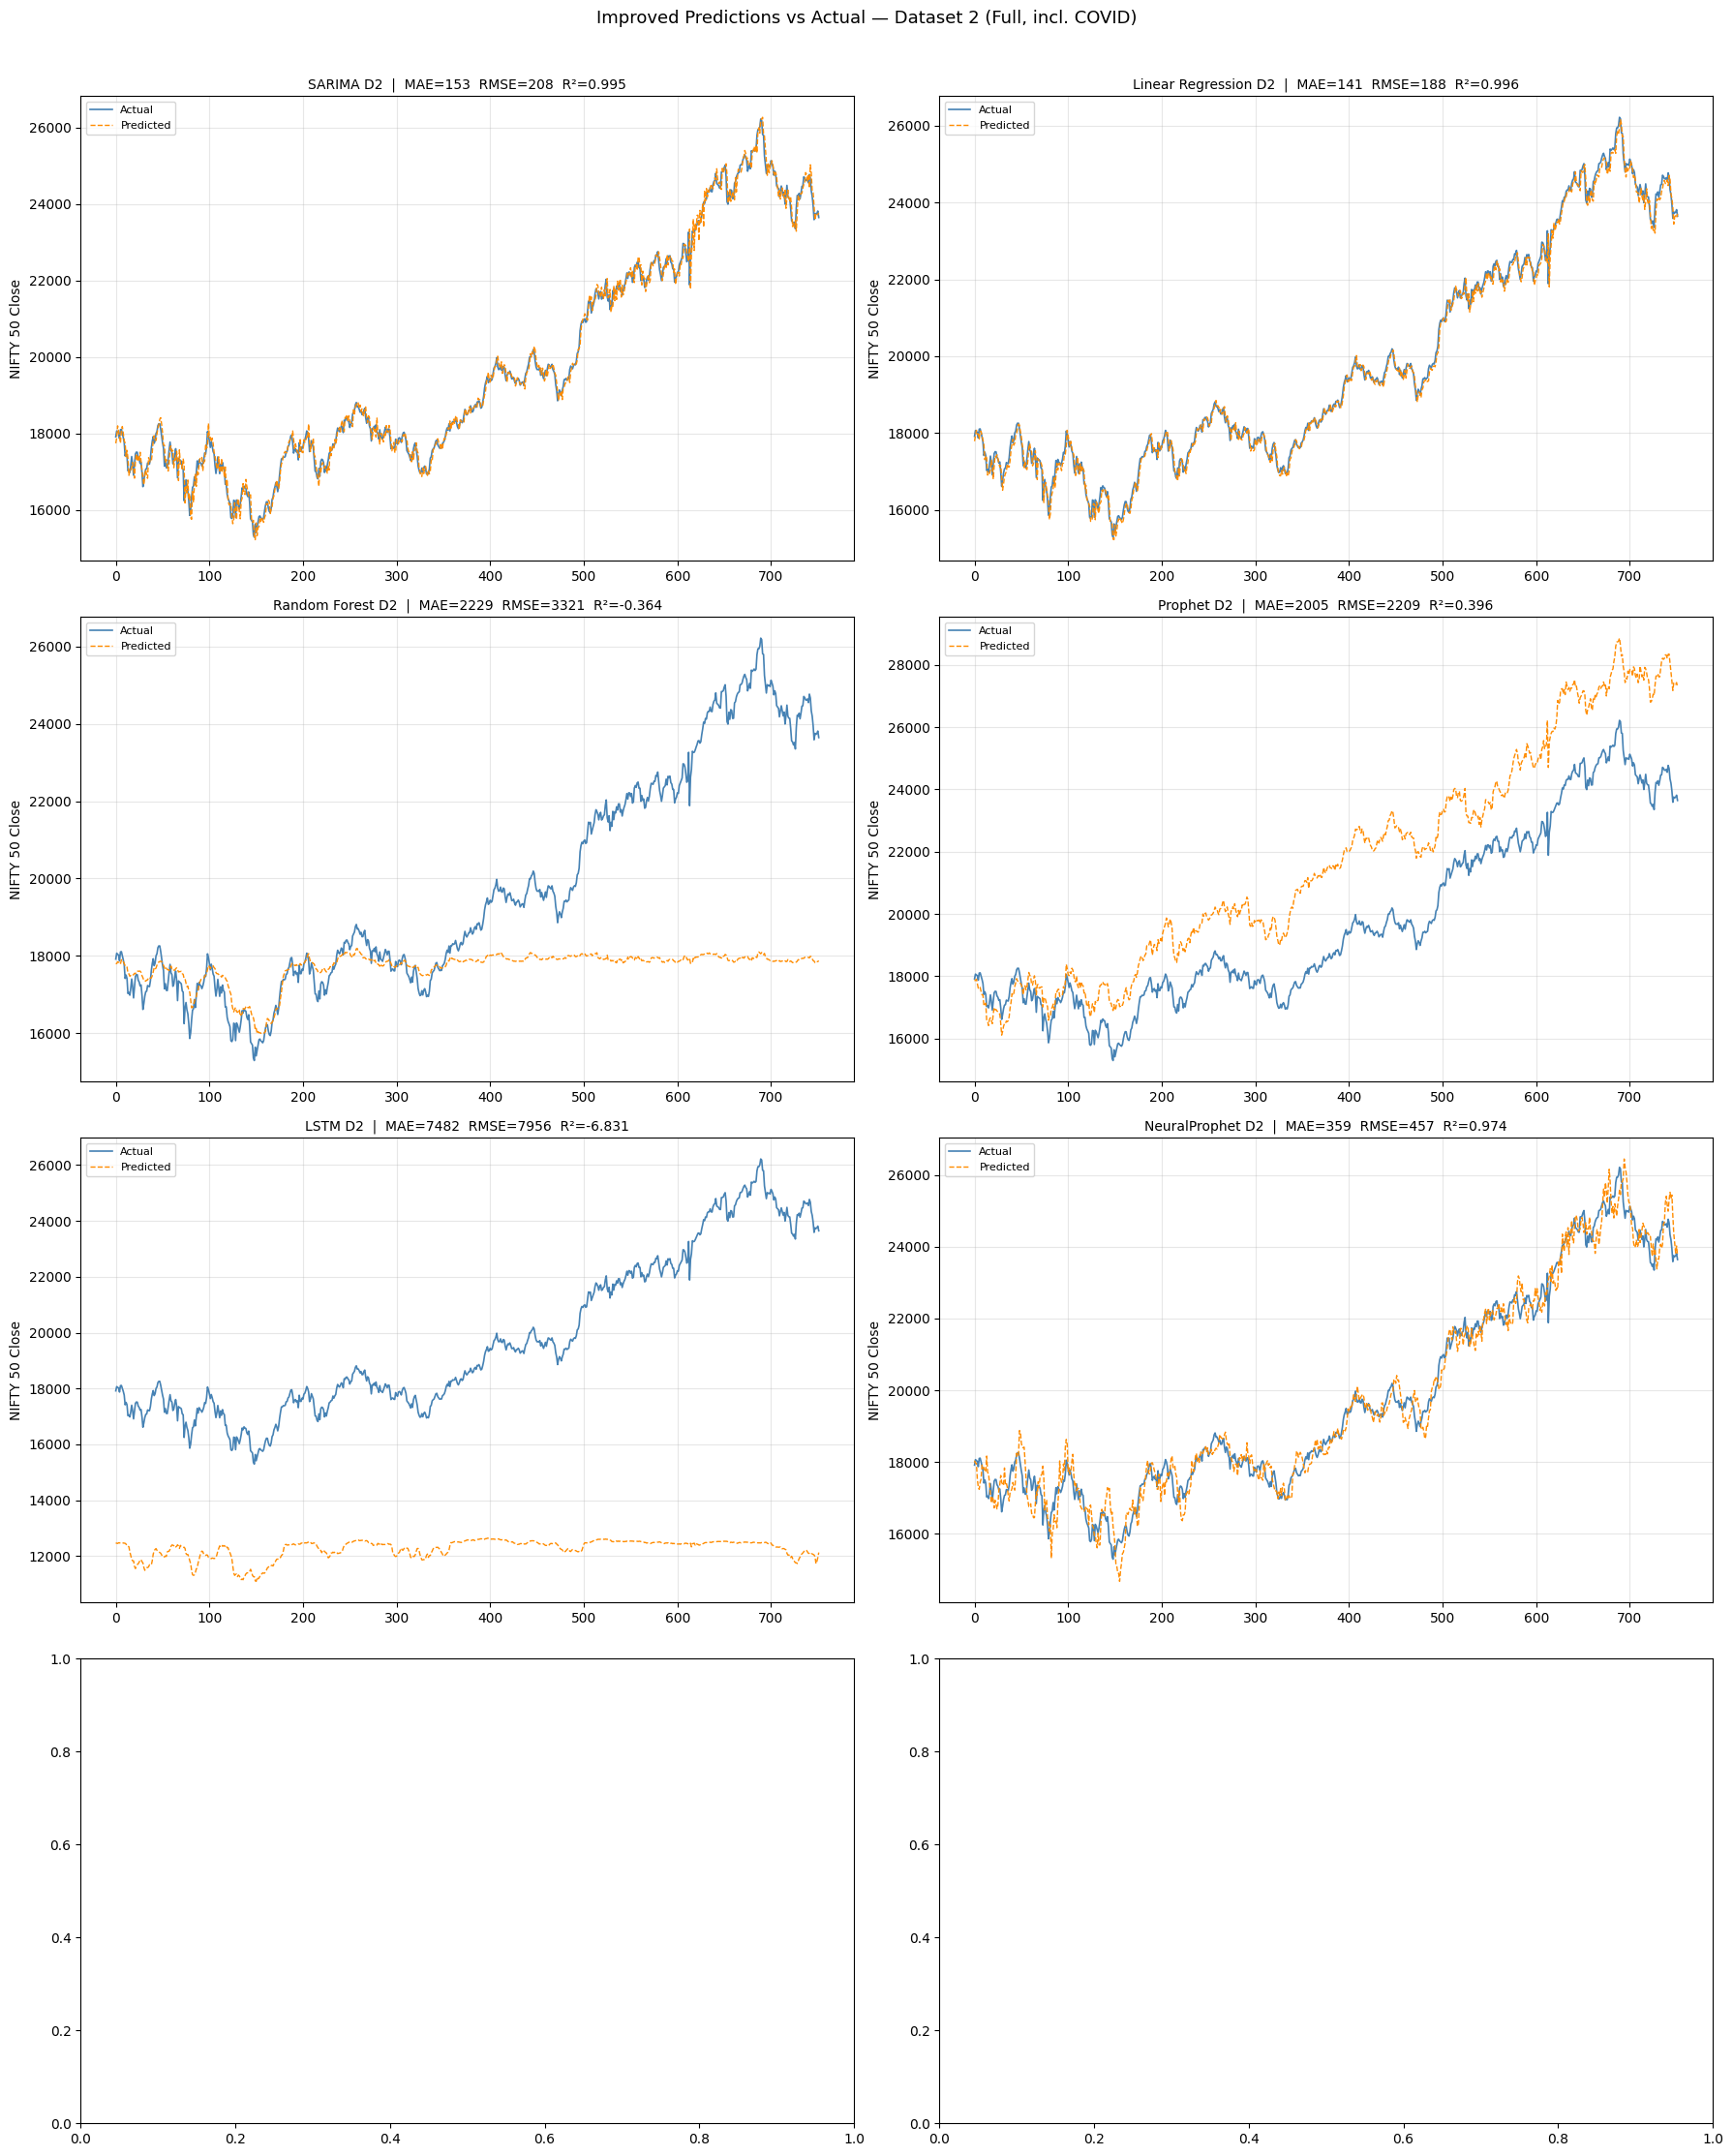

✅ Done. Results saved to /content/drive/MyDrive/NIFTY50_Forecast/data


In [19]:
# –– CELL 18: Visualisation ––

model_keys = [k for k in results if k.endswith('D2') and not k.startswith('baseline')]
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for ax, key in zip(axes, model_keys):
    r = results[key]
    ax.plot(r['y_true'], label='Actual',    linewidth=1.2, color='steelblue')
    ax.plot(r['y_pred'], label='Predicted', linewidth=1.0,
            linestyle='--', color='darkorange')
    ax.set_title(
        f"{r['label']}  |  MAE={r['MAE']:.0f}  RMSE={r['RMSE']:.0f}  R²={r['R2']:.3f}",
        fontsize=10)
    ax.set_ylabel('NIFTY 50 Close')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Improved Predictions vs Actual — Dataset 2 (Full, incl. COVID)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'model_comparison_improved_D2.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Done. Results saved to", DATA_DIR)

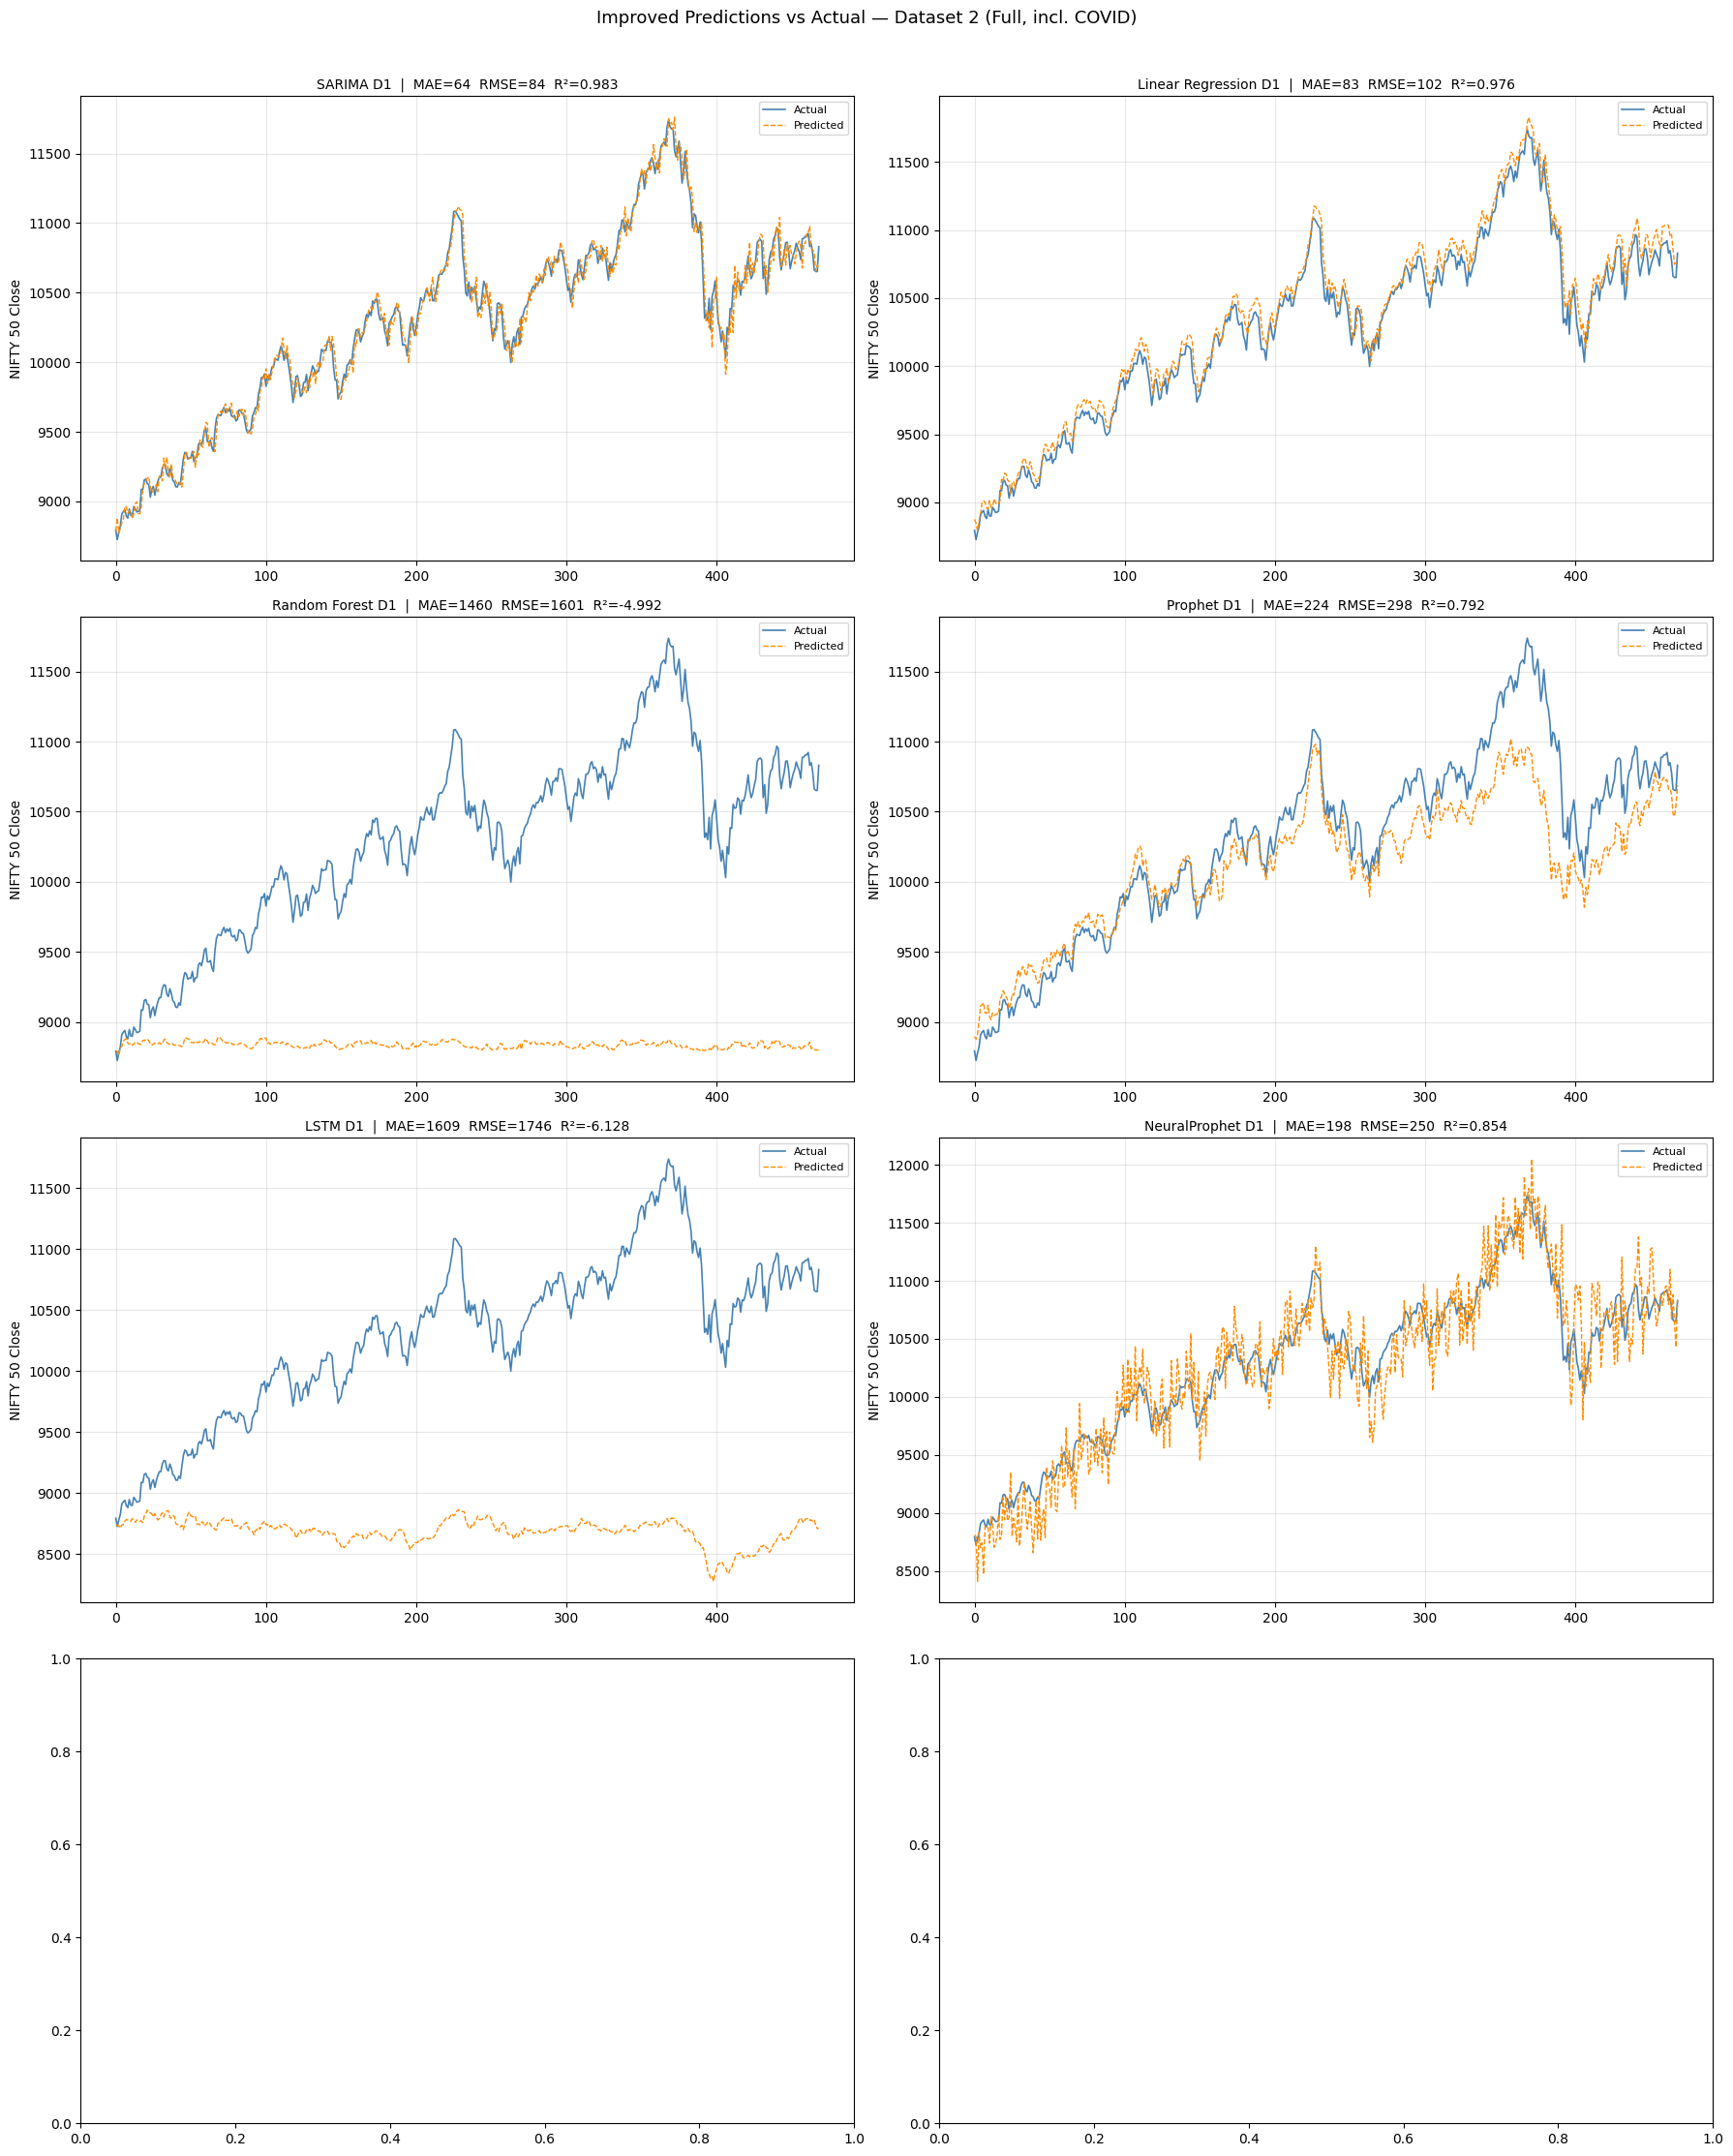

✅ Done. Results saved to /content/drive/MyDrive/NIFTY50_Forecast/data


In [20]:
# –– CELL 18: Visualisation ––

model_keys = [k for k in results if k.endswith('D1') and not k.startswith('baseline')]
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for ax, key in zip(axes, model_keys):
    r = results[key]
    ax.plot(r['y_true'], label='Actual',    linewidth=1.2, color='steelblue')
    ax.plot(r['y_pred'], label='Predicted', linewidth=1.0,
            linestyle='--', color='darkorange')
    ax.set_title(
        f"{r['label']}  |  MAE={r['MAE']:.0f}  RMSE={r['RMSE']:.0f}  R²={r['R2']:.3f}",
        fontsize=10)
    ax.set_ylabel('NIFTY 50 Close')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Improved Predictions vs Actual — Dataset 2 (Full, incl. COVID)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'model_comparison_improved_D2.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Done. Results saved to", DATA_DIR)

# Improved LSTM (returns)


In [21]:
import tensorflow as tf

# ── IMPROVED LSTM — Step 1: Prepare return-based data ─────────────────────────

def split_scale_lstm_returns(feat_df, target_series, test_ratio=0.2):
    """Split, scale features and return target. Returns arrays + scalers."""
    split = int(len(feat_df)*(1-test_ratio))

    tr_feat = feat_df.iloc[:split].values
    te_feat = feat_df.iloc[split:].values
    tr_tgt  = target_series.iloc[:split].values
    te_tgt  = target_series.iloc[split:].values

    scX = StandardScaler()
    tr_feat_sc = scX.fit_transform(tr_feat)
    te_feat_sc = scX.transform(te_feat)

    scY = StandardScaler()
    tr_tgt_sc = scY.fit_transform(tr_tgt.reshape(-1,1)).ravel()
    te_tgt_sc = scY.transform(te_tgt.reshape(-1,1)).ravel()

    # Dates of test period
    te_dates = feat_df.index[split:]
    # Actual Close prices for test period (for final evaluation)
    true_close = df_main.loc[te_dates, 'Close'].values
    # The actual Close one day before test starts (for reconstruction anchor)
    last_close = df_main.loc[feat_df.index[split-1], 'Close']

    return (tr_feat_sc, te_feat_sc, tr_tgt_sc, te_tgt_sc,
            scX, scY, last_close, true_close, te_dates)

# Define lf_d1, tgt_d1, lf_d2, tgt_d2
lf_d1 = df_d1[FINAL_FEATS]
tgt_d1 = df_d1['log_diff']
lf_d2 = df_d2[FINAL_FEATS]
tgt_d2 = df_d2['log_diff']

(Xlr_tr1, Xlr_te1, ylr_tr1, ylr_te1,
 scXl1, scYl1, lc1, tc1, td1) = split_scale_lstm_returns(lf_d1, tgt_d1)

(Xlr_tr2, Xlr_te2, ylr_tr2, ylr_te2,
 scXl2, scYl2, lc2, tc2, td2) = split_scale_lstm_returns(lf_d2, tgt_d2)

print(f"Return-LSTM D1: train={Xlr_tr1.shape} test={Xlr_te1.shape}  n_features={Xlr_tr1.shape[1]}")
print(f"Return-LSTM D2: train={Xlr_tr2.shape} test={Xlr_te2.shape}  n_features={Xlr_tr2.shape[1]}")

Return-LSTM D1: train=(1876, 37) test=(469, 37)  n_features=37
Return-LSTM D2: train=(3005, 37) test=(752, 37)  n_features=37


In [22]:
# ── IMPROVED LSTM — Step 2: Build sequences ───────────────────────────────────

def make_seq(X, y, lookback):
    Xs,ys = [],[]
    for i in range(lookback,len(X)):
        Xs.append(X[i-lookback:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

def make_test_seq(X_tr, X_te, y_te, lookback):
    bridge = np.concatenate([X_tr[-lookback:],X_te],axis=0)
    Xs,ys  = [],[]
    for i in range(lookback,len(bridge)):
        Xs.append(bridge[i-lookback:i]); ys.append(y_te[i-lookback])
    return np.array(Xs), np.array(ys)

Xrseq_tr1,yrseq_tr1 = make_seq(Xlr_tr1,ylr_tr1,LSTM_LOOKBACK)
Xrseq_te1,yrseq_te1 = make_test_seq(Xlr_tr1,Xlr_te1,ylr_te1,LSTM_LOOKBACK)
Xrseq_tr2,yrseq_tr2 = make_seq(Xlr_tr2,ylr_tr2,LSTM_LOOKBACK)
Xrseq_te2,yrseq_te2 = make_test_seq(Xlr_tr2,Xlr_te2,ylr_te2,LSTM_LOOKBACK)

print(f"Return sequences D1 train:{Xrseq_tr1.shape} | test:{Xrseq_te1.shape}")
print(f"Return sequences D2 train:{Xrseq_tr2.shape} | test:{Xrseq_te2.shape}")

Return sequences D1 train:(1816, 60, 37) | test:(469, 60, 37)
Return sequences D2 train:(2945, 60, 37) | test:(752, 60, 37)


In [23]:
# ── IMPROVED LSTM — Step 2: Build sequences ───────────────────────────────────

def make_seq(X, y, lookback):
    Xs,ys = [],[]
    for i in range(lookback,len(X)):
        Xs.append(X[i-lookback:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

def make_test_seq(X_tr, X_te, y_te, lookback):
    bridge = np.concatenate([X_tr[-lookback:],X_te],axis=0)
    Xs,ys  = [],[]
    for i in range(lookback,len(bridge)):
        Xs.append(bridge[i-lookback:i]); ys.append(y_te[i-lookback])
    return np.array(Xs), np.array(ys)

Xrseq_tr1,yrseq_tr1 = make_seq(Xlr_tr1,ylr_tr1,LSTM_LOOKBACK)
Xrseq_te1,yrseq_te1 = make_test_seq(Xlr_tr1,Xlr_te1,ylr_te1,LSTM_LOOKBACK)
Xrseq_tr2,yrseq_tr2 = make_seq(Xlr_tr2,ylr_tr2,LSTM_LOOKBACK)
Xrseq_te2,yrseq_te2 = make_test_seq(Xlr_tr2,Xlr_te2,ylr_te2,LSTM_LOOKBACK)

print(f"Return sequences D1 train:{Xrseq_tr1.shape} | test:{Xrseq_te1.shape}")
print(f"Return sequences D2 train:{Xrseq_tr2.shape} | test:{Xrseq_te2.shape}")


Return sequences D1 train:(1816, 60, 37) | test:(469, 60, 37)
Return sequences D2 train:(2945, 60, 37) | test:(752, 60, 37)


In [24]:
# ── IMPROVED LSTM — Step 3: Architecture + Training ──────────────────────────
# Key changes from original:
#   • Unidirectional stacked LSTM (not BiLSTM — worst per papers)
#   • Cosine LR schedule with warmup (smoother, avoids early overshoot)
#   • Gradient clipping (clipnorm=1.0) — critical for return prediction stability
#   • L2 regularisation on kernel weights
#   • Larger patience (35 epochs) — returns have lower SNR than price levels

from tensorflow.keras.callbacks import LearningRateScheduler

def build_improved_lstm(n_features, lookback):
    """
    Stacked UNIDIRECTIONAL LSTM — optimal architecture per Hamayel & Owda (2021).
    Predicts SCALED LOG-RETURNS (not price levels).
    """
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(lookback, n_features),
             kernel_regularizer=tf.keras.regularizers.l2(1e-5),
             recurrent_dropout=0.0),
        Dropout(0.25),

        LSTM(64, return_sequences=True,
             kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        Dropout(0.20),

        LSTM(32, return_sequences=False),
        Dropout(0.15),

        Dense(32, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        Dropout(0.10),
        Dense(16, activation='relu'),
        Dense(1)   # Linear — predicts SCALED log-return
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss='mse', metrics=['mae']
    )
    return model

def cosine_schedule(warmup=10, base_lr=1e-3, total=200):
    def schedule(epoch, lr):
        if epoch < warmup:
            return base_lr * (epoch + 1) / warmup
        progress = (epoch - warmup) / (total - warmup)
        return base_lr * 0.5 * (1 + np.cos(np.pi * progress))
    return LearningRateScheduler(schedule, verbose=0)

def train_improved_lstm(Xseq_tr, yseq_tr, epochs=200, batch_size=32, verbose=1):
    n_feat   = Xseq_tr.shape[2]
    lookback = Xseq_tr.shape[1]
    model = build_improved_lstm(n_feat, lookback)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=35,
                      restore_best_weights=True, min_delta=1e-7),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=15, min_lr=1e-6, verbose=0),
        cosine_schedule(warmup=10, base_lr=1e-3, total=epochs),
    ]
    history = model.fit(
        Xseq_tr, yseq_tr,
        validation_split=0.15,
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=verbose
    )
    best_val = min(history.history['val_loss'])
    best_ep  = int(np.argmin(history.history['val_loss'])) + 1
    print(f"  → Stopped at epoch {len(history.history['val_loss'])} | best val_loss={best_val:.6f} at ep {best_ep}")
    return model, history

def reconstruct_price_1step(pred_ret_sc, scY, last_close, true_close):
    """
    Reconstruct price using ACTUAL previous price (no error compounding).
    pred_price[i] = actual_price[i-1] * exp(predicted_return[i])
    This is the correct 1-step-ahead evaluation.
    """
    pred_ret  = scY.inverse_transform(pred_ret_sc.reshape(-1,1)).ravel()
    prev_prices = np.concatenate([[last_close], true_close[:-1]])
    pred_prices = prev_prices * np.exp(pred_ret)
    return pred_prices, true_close

print("✅ Improved LSTM architecture defined.")
print(f"   Lookback={LSTM_LOOKBACK} | Cosine LR | ClipNorm=1.0 | L2=1e-5")

✅ Improved LSTM architecture defined.
   Lookback=60 | Cosine LR | ClipNorm=1.0 | L2=1e-5


In [25]:
# ── IMPROVED LSTM — Step 4a: Single-shot training (fast baseline) ─────────────
# Trains once on full training set.

def run_improved_lstm_single(Xrseq_tr, yrseq_tr, Xrseq_te, yrseq_te,
                              scY, last_close, true_close, label,
                              epochs=200, batch_size=32):
    print(f"\nTraining {label}...")
    model, _ = train_improved_lstm(Xrseq_tr, yrseq_tr, epochs, batch_size, verbose=0)
    pred_ret_sc = model.predict(Xrseq_te, verbose=0).ravel()
    pred_prices, true_prices = reconstruct_price_1step(pred_ret_sc, scY, last_close, true_close)
    return evaluate_raw(true_prices, pred_prices, label), model

results['lstm_imp_D1'], lstm_imp_d1 = run_improved_lstm_single(
    Xrseq_tr1, yrseq_tr1, Xrseq_te1, yrseq_te1,
    scYl1, lc1, tc1, 'LSTM Improved (returns) D1')

results['lstm_imp_D2'], lstm_imp_d2 = run_improved_lstm_single(
    Xrseq_tr2, yrseq_tr2, Xrseq_te2, yrseq_te2,
    scYl2, lc2, tc2, 'LSTM Improved (returns) D2')



Training LSTM Improved (returns) D1...
  → Stopped at epoch 56 | best val_loss=0.593630 at ep 21
LSTM Improved (returns) D1                 RMSE=    74.8 | MAE=   56.6 | MAPE= 0.55% | R²=0.9869

Training LSTM Improved (returns) D2...
  → Stopped at epoch 53 | best val_loss=1.861535 at ep 18
LSTM Improved (returns) D2                 RMSE=   176.2 | MAE=  128.4 | MAPE= 0.66% | R²=0.9962


In [26]:
# ── IMPROVED LSTM — Step 4b: Walk-Forward with Refit (best version) ────────────
# Retrains on an EXPANDING WINDOW every RETRAIN_FREQ days.
# Crucial for regime changes: COVID crash, post-COVID bull, etc.
# Slower (~15-20 min total) but much better adaptation.

RETRAIN_FREQ = 60 # Define retraining frequency (e.g., every 60 trading days)

def run_lstm_walkforward(
    feat_df, target_series, test_ratio=0.2,
    lookback=LSTM_LOOKBACK, retrain_freq=RETRAIN_FREQ,
    label='LSTM Walk-Forward', epochs=150, batch_size=32
):
    split = int(len(feat_df)*(1-test_ratio))
    all_pred_ret = []

    # Pre-compute ALL scaled data (we re-fit scaler at each window)
    feat_arr = feat_df.values
    tgt_arr  = target_series.values

    # Actual Close prices for test period
    te_dates  = feat_df.index[split:]
    true_close = df_main.loc[te_dates, 'Close'].values
    last_close = df_main.loc[feat_df.index[split-1], 'Close']

    n_test = len(feat_arr) - split
    chunk_boundaries = list(range(0, n_test, retrain_freq)) + [n_test]

    for chunk_idx, chunk_start in enumerate(chunk_boundaries[:-1]):
        chunk_end   = chunk_boundaries[chunk_idx+1]
        window_end  = split + chunk_start          # end of current training window
        n_chunk     = chunk_end - chunk_start

        print(f"  Chunk {chunk_idx+1}: train rows 0–{window_end} "              f"| predict {n_chunk} steps")

        # ── Scale on expanding window ──
        X_win = feat_arr[:window_end]
        y_win = tgt_arr [:window_end]
        scX_c = StandardScaler(); X_win_sc = scX_c.fit_transform(X_win)
        scY_c = StandardScaler(); y_win_sc = scY_c.fit_transform(
                                                  y_win.reshape(-1,1)).ravel()

        # ── Build training sequences ──
        Xseq, yseq = make_seq(X_win_sc, y_win_sc, lookback)
        if len(Xseq) < 50:
            print("   Skipping — too few training sequences."); continue

        # ── Train model on this window ──
        model, _ = train_improved_lstm(Xseq, yseq, epochs, batch_size, verbose=0)

        # ── Scale and predict the next chunk ──
        X_chunk_raw = feat_arr[window_end:window_end+n_chunk]
        X_chunk_sc  = scX_c.transform(X_chunk_raw)

        for i in range(n_chunk):
            # Bridge: last `lookback` training rows + test rows seen so far
            hist_sc   = X_win_sc[-lookback:]
            future_sc = X_chunk_sc[:i]
            ctx = np.concatenate([hist_sc, future_sc], axis=0)
            seq = ctx[-lookback:]   # shape (lookback, n_features)
            if len(seq) < lookback:
                # pad with zeros (rare edge case at very start)
                seq = np.pad(seq, ((lookback-len(seq),0),(0,0)))
            p = model.predict(seq.reshape(1,lookback,-1),verbose=0)[0,0]
            all_pred_ret.append(scY_c.inverse_transform([[p]])[0,0])

    # ── Reconstruct prices (1-step-ahead, no error compounding) ──
    all_pred_ret = np.array(all_pred_ret)
    pred_prices, true_prices = reconstruct_price_1step(
        all_pred_ret, # already unscaled
        type('FakeScaler', (), {  # passthrough scaler — data already unscaled
            'inverse_transform': lambda self,x: x})(),
        last_close, true_close
    )
    # Override: reconstruct_price_1step expects scaled input; use direct calc here
    prev = np.concatenate([[last_close], true_close[:-1]])
    pred_prices = prev * np.exp(all_pred_ret[:len(prev)])
    n = min(len(pred_prices), len(true_close))
    return evaluate_raw(true_close[:n], pred_prices[:n], label)

# ── Run walk-forward LSTM ──
results['lstm_wf_D1'] = run_lstm_walkforward(
    lf_d1, tgt_d1, label='LSTM Walk-Forward D1')

results['lstm_wf_D2'] = run_lstm_walkforward(
    lf_d2, tgt_d2, label='LSTM Walk-Forward D2')

  Chunk 1: train rows 0–1876 | predict 60 steps
  → Stopped at epoch 42 | best val_loss=0.595399 at ep 7
  Chunk 2: train rows 0–1936 | predict 60 steps
  → Stopped at epoch 47 | best val_loss=0.445114 at ep 12
  Chunk 3: train rows 0–1996 | predict 60 steps
  → Stopped at epoch 52 | best val_loss=0.392276 at ep 17
  Chunk 4: train rows 0–2056 | predict 60 steps
  → Stopped at epoch 39 | best val_loss=0.361105 at ep 4
  Chunk 5: train rows 0–2116 | predict 60 steps
  → Stopped at epoch 51 | best val_loss=0.362440 at ep 16
  Chunk 6: train rows 0–2176 | predict 60 steps
  → Stopped at epoch 45 | best val_loss=0.303975 at ep 10
  Chunk 7: train rows 0–2236 | predict 60 steps
  → Stopped at epoch 44 | best val_loss=0.305456 at ep 9
  Chunk 8: train rows 0–2296 | predict 49 steps
  → Stopped at epoch 38 | best val_loss=0.429914 at ep 3
LSTM Walk-Forward D1                       RMSE=    75.2 | MAE=   56.9 | MAPE= 0.55% | R²=0.9868
  Chunk 1: train rows 0–3005 | predict 60 steps
  → Stopped

# New LSTM results

In [27]:
# ── Results Summary ───────────────────────────────────────────────────────────
print("\n" + "="*85)
print(" MODEL COMPARISON — NIFTY 50 FORECASTING")
print("="*85)
rows = []
for key,r in results.items():
    rows.append({'Model':r['label'],'RMSE':round(r['RMSE'],2),
                 'MAE':round(r['MAE'],2),'MAPE(%)':round(r['MAPE'],3),
                 'R²':round(r['R2'],4)})
summary = pd.DataFrame(rows).sort_values('MAPE(%)')
print(summary.to_string(index=False))
print("="*85)
summary.to_csv(os.path.join(DATA_DIR,'model_comparison_final.csv'),index=False)

# Highlight LSTM improvements
print("\n📊 LSTM Performance Comparison:")
lstm_keys = [k for k in results if 'lstm' in k.lower() or 'orig' in k.lower()]
for k in lstm_keys:
    r = results[k]
    print(f"  {r['label']:<46s} MAPE={r['MAPE']:.2f}% | MAE={r['MAE']:.1f} | R²={r['R2']:.4f}")



 MODEL COMPARISON — NIFTY 50 FORECASTING
                     Model    RMSE     MAE  MAPE(%)      R²
               Baseline D1   74.83   56.68    0.548  0.9869
LSTM Improved (returns) D1   74.75   56.64    0.548  0.9869
      LSTM Walk-Forward D1   75.21   56.90    0.550  0.9868
                 SARIMA D1   84.46   63.60    0.615  0.9833
LSTM Improved (returns) D2  176.19  128.37    0.664  0.9962
               Baseline D2  176.30  128.66    0.665  0.9962
      LSTM Walk-Forward D2  177.24  128.98    0.667  0.9961
      Linear Regression D2  188.44  141.17    0.722  0.9956
                 SARIMA D2  207.69  153.46    0.789  0.9947
      Linear Regression D1  102.01   82.88    0.803  0.9757
          NeuralProphet D2  457.28  358.67    1.856  0.9741
          NeuralProphet D1  249.67  197.54    1.926  0.8542
                Prophet D1  297.88  223.97    2.109  0.7925
          Random Forest D2 3320.93 2229.12    9.893 -0.3645
                Prophet D2 2209.06 2005.50    9.957  0.396

# Directional Accuracy

In [40]:
# ── DIRECTIONAL ACCURACY HELPER ──────────────────────────────────────────────
import numpy as np
import pandas as pd

def directional_accuracy(y_true, y_pred):
    """
    What % of the time did the model correctly predict UP vs DOWN?

    y_true, y_pred: arrays of PRICE LEVELS (already reconstructed).

    Logic:
      - actual direction  = sign(today's true price  - yesterday's true price)
      - predicted direction = sign(today's pred price - yesterday's true price)
    We compare predicted against yesterday's ACTUAL price because that's what
    the model had available — avoids giving credit for knowing the true level.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Actual moves: did market go up or down?
    actual_dir = np.sign(y_true[1:] - y_true[:-1])

    # Predicted moves: did model say it would go up or down?
    # Compare predicted price today vs actual price yesterday
    pred_dir   = np.sign(y_pred[1:] - y_true[:-1])

    correct    = np.sum(actual_dir == pred_dir)
    total      = len(actual_dir)
    acc        = correct / total * 100
    return acc, correct, total

In [41]:
# ── DIRECTIONAL ACCURACY — ALL MODELS ────────────────────────────────────────
# This cell works on your existing `results` dict.
# Every entry in results has 'y_true' and 'y_pred' as price-level arrays.

print("=" * 65)
print(f"{'Model':<42s} {'Dir Acc':>8}  {'Correct':>7}  {'Total':>6}")
print("=" * 65)

# Define display order — edit keys to match what you have in your results dict
ordered_keys = [
    # Baseline
    'baseline_D1', 'baseline_D2',
    # SARIMA
    'sarima_D1',   'sarima_D2',
    # NeuralProphet (original)
    'np_D1',       'np_D2',
    # NeuralProphet Walk-Forward
    'np_wf_D1',    'np_wf_D2',
    # LSTM (original bidirectional)
    'lstm_D1',     'lstm_D2',
    # Improved LSTM single-shot
    'lstm_imp_D1', 'lstm_imp_D2',
    # Improved LSTM walk-forward
    'lstm_wf_D1',  'lstm_wf_D2',
]

dir_acc_results = {}

for key in ordered_keys:
    if key not in results:
        print(f"  [skipped — not in results: {key}]")
        continue
    r = results[key]
    acc, correct, total = directional_accuracy(r['y_true'], r['y_pred'])
    dir_acc_results[key] = acc
    flag = " ◀ STRONG" if acc >= 55 else (" ◀ BASELINE" if key.startswith('baseline') else "")
    print(f"  {r['label']:<42s} {acc:>6.2f}%  {correct:>7}  {total:>6}{flag}")

print("=" * 65)
print("\nBaseline always predicts zero change → its directional accuracy")
print("reflects only the natural market up-bias, NOT learned signals.")
print("Any model significantly above baseline here is genuinely learning direction.")

Model                                       Dir Acc  Correct   Total
  Baseline D1                                  0.21%        1     468 ◀ BASELINE
  Baseline D2                                  0.13%        1     751 ◀ BASELINE
  SARIMA D1                                   52.14%      244     468
  SARIMA D2                                   50.07%      376     751
  NeuralProphet D1                            51.50%      241     468
  NeuralProphet D2                            49.00%      368     751
  [skipped — not in results: np_wf_D1]
  [skipped — not in results: np_wf_D2]
  LSTM D1                                     45.51%      213     468
  LSTM D2                                     46.21%      347     751
  LSTM Improved (returns) D1                  55.56%      260     468 ◀ STRONG
  LSTM Improved (returns) D2                  53.66%      403     751
  LSTM Walk-Forward D1                        50.00%      234     468
  LSTM Walk-Forward D2                        53.66%

# NEW ML

# Random Forest

In [51]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import RandomForestRegressor

def run_rf_logreturns(df_full, feat_df, test_ratio=0.2, label='Random Forest'):
    split = int(len(feat_df) * (1 - test_ratio))

    # ── Features: scale on train only ──
    X_tr_raw = feat_df.iloc[:split].values
    X_te_raw = feat_df.iloc[split:].values
    scX = StandardScaler()
    X_tr = scX.fit_transform(X_tr_raw)
    X_te = scX.transform(X_te_raw)

    # ── Target: log returns, scaled ──
    log_ret = df_full['log_diff']
    y_tr_raw = log_ret.iloc[:split].values
    y_te_raw = log_ret.iloc[split:].values
    scY = StandardScaler()
    y_tr = scY.fit_transform(y_tr_raw.reshape(-1, 1)).ravel()

    # ── Efficient hyperparameter search ──
    param_grid = {
        'n_estimators'    : [200, 400, 600],
        'max_depth'       : [8, 12, 16, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features'    : [0.5, 0.7, 'sqrt'],
    }
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    search = HalvingRandomSearchCV(
        rf, param_grid,
        factor=3,                        # triples resources each round → much faster
        scoring='neg_mean_absolute_error',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_tr, y_tr)
    best_rf = search.best_estimator_
    print(f"  {label} → best params: {search.best_params_}")

    # ── Predict log returns, then reconstruct price ──
    pred_ret_sc = best_rf.predict(X_te)
    pred_ret    = scY.inverse_transform(pred_ret_sc.reshape(-1, 1)).ravel()

    te_dates    = feat_df.index[split:]
    true_close  = df_full.loc[te_dates, 'Close'].values
    last_close  = df_full.loc[feat_df.index[split - 1], 'Close']

    prev_prices = np.concatenate([[last_close], true_close[:-1]])
    pred_prices = prev_prices * np.exp(pred_ret)

    return evaluate_raw(true_close, pred_prices, label), best_rf

results['rf_D1'], rf_model_d1 = run_rf_logreturns(df_d1, df_d1[FINAL_FEATS], label='Random Forest D1')
results['rf_D2'], rf_model_d2 = run_rf_logreturns(df_d2, df_d2[FINAL_FEATS], label='Random Forest D2')

  Random Forest D1 → best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8}
Random Forest D1                           RMSE=    79.7 | MAE=   63.1 | MAPE= 0.61% | R²=0.9851
  Random Forest D2 → best params: {'n_estimators': 600, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8}
Random Forest D2                           RMSE=   181.3 | MAE=  131.6 | MAPE= 0.68% | R²=0.9959


# Prophet new

In [52]:
# ── CELL 13: Prophet — Log Returns (drop-in replacement) ─────────────────────
# Prophet fits on log_diff (stationary), not Close (non-stationary).
# Price reconstruction: pred_price[i] = actual_price[i-1] * exp(pred_return[i])
# Disables mcmc_samples and parallelises Stan via n_jobs to speed up training.

from prophet import Prophet

def run_prophet_logreturns(tr_df, te_df, macro_cols, label):
    # ── Prepare Prophet dataframes on log returns ──
    tr_p = tr_df[['log_diff'] + macro_cols].reset_index().rename(
        columns={'Date': 'ds', 'log_diff': 'y'})
    te_p = te_df[['log_diff'] + macro_cols].reset_index().rename(
        columns={'Date': 'ds', 'log_diff': 'y'})

    # Normalise macro regressors on train to stabilise Stan sampler
    macro_scalers = {}
    for col in macro_cols:
        mu, sigma = tr_p[col].mean(), tr_p[col].std() + 1e-10
        macro_scalers[col] = (mu, sigma)
        tr_p[col] = (tr_p[col] - mu) / sigma
        te_p[col] = (te_p[col] - mu) / sigma

    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05,    # tighter prior — returns are mean-reverting
        seasonality_prior_scale=5,
        seasonality_mode='additive',     # additive correct for returns (not price levels)
        uncertainty_samples=0,           # skip uncertainty → ~3x faster training
    )
    for col in macro_cols:
        m.add_regressor(col)

    import logging
    logging.getLogger('prophet').setLevel(logging.WARNING)  # suppress verbose Stan output
    m.fit(tr_p)

    # ── Predict returns on test period ──
    future     = te_p[['ds'] + macro_cols]
    fc         = m.predict(future)
    pred_ret   = fc['yhat'].values

    # ── Reconstruct price: anchor on actual previous close ──
    true_close  = te_df['Close'].values
    last_close  = tr_df['Close'].iloc[-1]
    prev_prices = np.concatenate([[last_close], true_close[:-1]])
    pred_prices = prev_prices * np.exp(pred_ret)

    return evaluate_raw(true_close, pred_prices, label)

results['prophet_D1'] = run_prophet_logreturns(tr1, te1, SIGNIFICANT_MACROS, 'Prophet D1')
results['prophet_D2'] = run_prophet_logreturns(tr2, te2, SIGNIFICANT_MACROS, 'Prophet D2')

Prophet D1                                 RMSE=    98.6 | MAE=   72.4 | MAPE= 0.69% | R²=0.9773
Prophet D2                                 RMSE=   231.4 | MAE=  177.3 | MAPE= 0.88% | R²=0.9934


# XG Boost New

In [53]:
# ── NEW CELL: XGBoost — Log Returns ───────────────────────────────────────────
# Trains XGBoost on scaled log returns, identical pipeline to improved LSTM.
# Uses 'hist' tree method (GPU-ready, fast on CPU too) + early stopping.
# Price reconstruction: pred_price[i] = actual_price[i-1] * exp(pred_return[i])

import xgboost as xgb

def run_xgb_logreturns(df_full, feat_df, test_ratio=0.2, label='XGBoost'):
    split = int(len(feat_df) * (1 - test_ratio))
    val_split = int(split * 0.9)  # last 10% of train as validation for early stopping

    # ── Features ──
    X_raw = feat_df.values
    scX   = StandardScaler()
    X_sc  = scX.fit_transform(X_raw[:split])   # fit on train only
    X_te  = scX.transform(X_raw[split:])

    X_tr_sub  = X_sc[:val_split]
    X_val_sub = X_sc[val_split:]

    # ── Target: log returns, scaled ──
    log_ret  = df_full['log_diff'].values
    scY      = StandardScaler()
    y_tr_sc  = scY.fit_transform(log_ret[:split].reshape(-1, 1)).ravel()

    y_tr_sub  = y_tr_sc[:val_split]
    y_val_sub = y_tr_sc[val_split:]

    # ── Train XGBoost ──
    model = xgb.XGBRegressor(
        n_estimators        = 1000,         # generous upper bound; early stopping exits early
        learning_rate       = 0.03,
        max_depth           = 6,
        subsample           = 0.8,
        colsample_bytree    = 0.8,
        min_child_weight    = 3,
        reg_alpha           = 0.1,          # L1
        reg_lambda          = 1.0,          # L2
        tree_method         = 'hist',       # fast; uses GPU automatically if available
        device              = 'cuda' if xgb.__version__ >= '2' else None,
        early_stopping_rounds = 50,
        eval_metric         = 'mae',
        random_state        = 42,
        n_jobs              = -1,
        verbosity           = 0,
    )
    model.fit(
        X_tr_sub, y_tr_sub,
        eval_set=[(X_val_sub, y_val_sub)],
        verbose=False
    )
    print(f"  {label} → best iteration: {model.best_iteration}")

    # ── Predict log returns, reconstruct price ──
    pred_ret_sc  = model.predict(X_te)
    pred_ret     = scY.inverse_transform(pred_ret_sc.reshape(-1, 1)).ravel()

    te_dates    = feat_df.index[split:]
    true_close  = df_full.loc[te_dates, 'Close'].values
    last_close  = df_full.loc[feat_df.index[split - 1], 'Close']

    prev_prices = np.concatenate([[last_close], true_close[:-1]])
    pred_prices = prev_prices * np.exp(pred_ret)

    return evaluate_raw(true_close, pred_prices, label), model

# Install xgboost if not already present
import subprocess, sys
try:
    import xgboost as xgb
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

results['xgb_D1'], xgb_model_d1 = run_xgb_logreturns(df_d1, df_d1[FINAL_FEATS], label='XGBoost D1')
results['xgb_D2'], xgb_model_d2 = run_xgb_logreturns(df_d2, df_d2[FINAL_FEATS], label='XGBoost D2')

  XGBoost D1 → best iteration: 12
XGBoost D1                                 RMSE=    75.3 | MAE=   57.1 | MAPE= 0.55% | R²=0.9867
  XGBoost D2 → best iteration: 1
XGBoost D2                                 RMSE=   176.7 | MAE=  128.4 | MAPE= 0.66% | R²=0.9961


In [54]:
import pandas as pd

dir_acc_summary = pd.DataFrame([
    {'Model': results[k]['label'], 'Directional Accuracy (%)': v}
    for k, v in dir_acc_results.items()
]).sort_values('Directional Accuracy (%)', ascending=False)

print("\n===== DIRECTIONAL ACCURACY COMPARISON =====")
print(dir_acc_summary.to_string(index=False))
print("===========================================")


===== DIRECTIONAL ACCURACY COMPARISON =====
                     Model  Directional Accuracy (%)
LSTM Improved (returns) D1                 55.555556
     Always Up Baseline D1                 54.487179
LSTM Improved (returns) D2                 53.661784
     Always Up Baseline D2                 53.661784
      LSTM Walk-Forward D2                 53.661784
                 SARIMA D1                 52.136752
          NeuralProphet D1                 51.495726
                 SARIMA D2                 50.066578
      LSTM Walk-Forward D1                 50.000000
          NeuralProphet D2                 49.001332
          Random Forest D2                 47.137150
                   LSTM D2                 46.205060
          Random Forest D1                 45.940171
                   LSTM D1                 45.512821
               Baseline D1                  0.213675
               Baseline D2                  0.133156


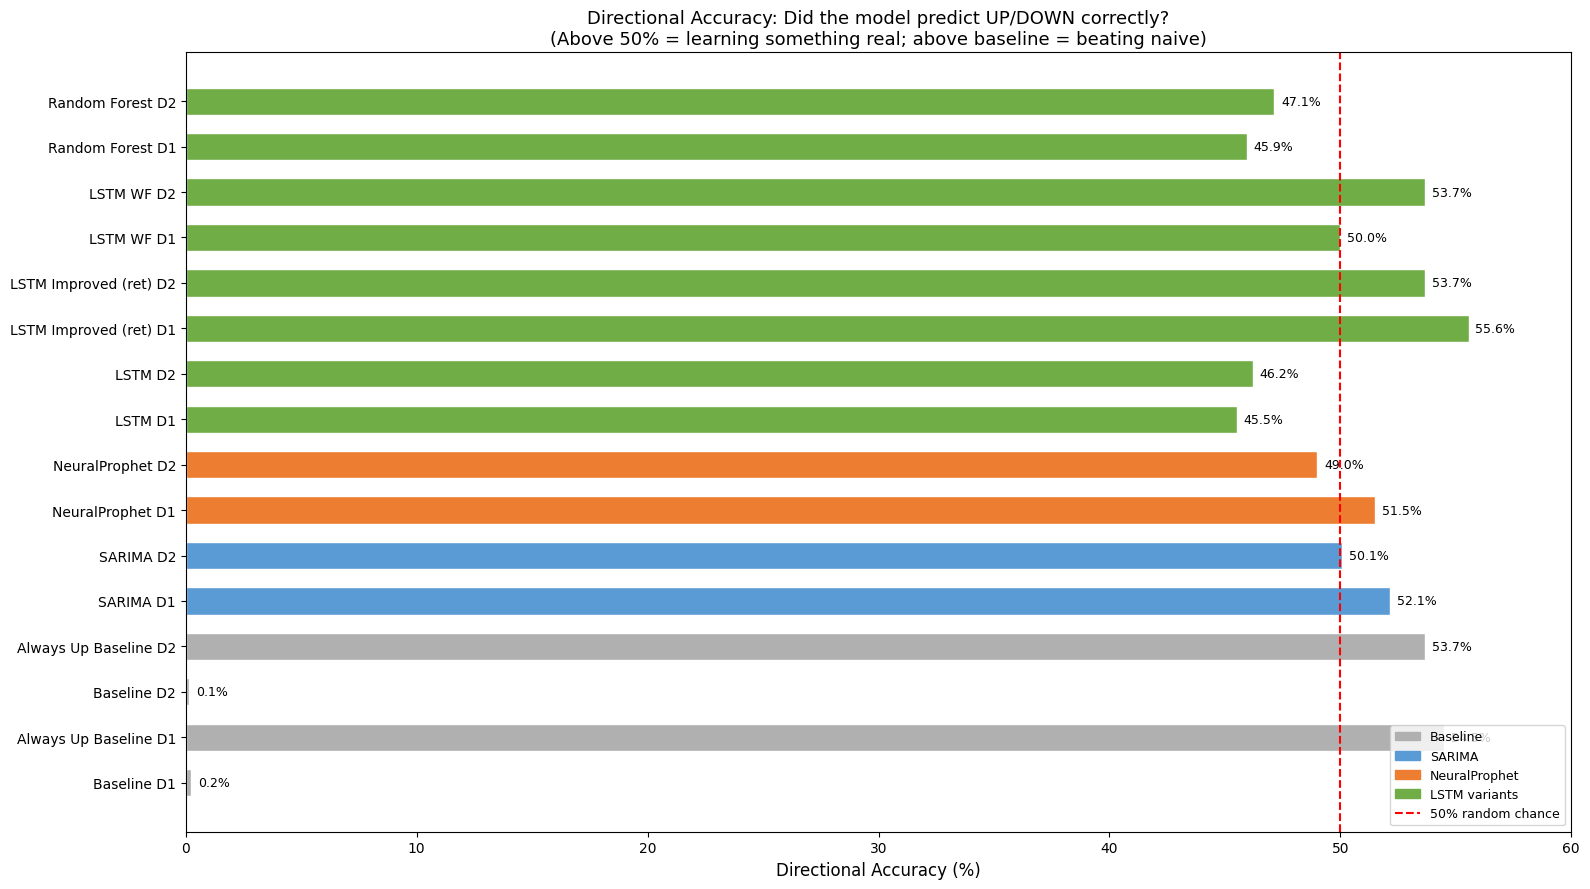

✅ Chart saved → directional_accuracy.png


In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = []
values = []
colors = []

color_map = {
    'baseline': '#b0b0b0',
    'sarima':   '#5b9bd5',
    'np':       '#ed7d31',
    'lstm':     '#70ad47',
}

for key, acc in dir_acc_results.items():
    if key not in results:
        continue
    # Simplify labels
    short_label = results[key]['label'].replace('(returns)', '(ret)').replace('Walk-Forward', 'WF')
    labels.append(short_label)
    values.append(acc)

    if   'baseline' in key: colors.append(color_map['baseline'])
    elif 'sarima'   in key: colors.append(color_map['sarima'])
    elif 'np'       in key: colors.append(color_map['np'])
    else:                   colors.append(color_map['lstm'])

fig, ax = plt.subplots(figsize=(16, 9)) # Increased figure size
bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.6)

# 50% line = pure random guessing
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='50% (random guess)')

# Annotate each bar
for bar, val in zip(bars, values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Directional Accuracy (%)', fontsize=12)
ax.set_title('Directional Accuracy: Did the model predict UP/DOWN correctly?\n'
             '(Above 50% = learning something real; above baseline = beating naive)', fontsize=13)
ax.set_xlim(0, 60) # Adjusted x-axis limits to better fit data

legend_patches = [
    mpatches.Patch(color=color_map['baseline'], label='Baseline'),
    mpatches.Patch(color=color_map['sarima'],   label='SARIMA'),
    mpatches.Patch(color=color_map['np'],        label='NeuralProphet'),
    mpatches.Patch(color=color_map['lstm'],      label='LSTM variants'),
    plt.Line2D([0],[0], color='red', linestyle='--', label='50% random chance'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'directional_accuracy.png'), dpi=150)
plt.show()
print("✅ Chart saved → directional_accuracy.png")

# Neural Prophet Improved


In [28]:
import pandas as pd
import numpy as np
from neuralprophet import NeuralProphet

def prepare_neuralprophet_returns(df_main, test_ratio=0.2):
    """
    Convert Close prices → log-returns for NeuralProphet.
    Returns train/test NP dataframes + reconstruction anchors.
    """
    df = df_main[['Close']].copy()

    # Log-returns (stationary target — same fix as improved LSTM)
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    df = df.dropna()

    # NeuralProphet requires columns: ds (datetime), y (target)
    np_df = pd.DataFrame({
        'ds': df.index,
        'y':  df['log_return'].values
    })

    split = int(len(np_df) * (1 - test_ratio))

    train_df = np_df.iloc[:split].reset_index(drop=True)
    test_df  = np_df.iloc[split:].reset_index(drop=True)

    # Anchors for price reconstruction (same as LSTM)
    te_dates   = df.index[split:]
    true_close = df_main.loc[te_dates, 'Close'].values
    last_close = df_main.loc[df.index[split - 1], 'Close']

    return train_df, test_df, true_close, last_close, te_dates

In [29]:
def add_stationary_regressors(df_main, np_df, test_ratio=0.2):
    """
    Add return-based, bounded regressors — no raw prices.
    Mirrors the 'stationary-only features' fix from improved LSTM.
    """
    df = df_main[['Close', 'Volume']].copy()

    # Return-based features (stationary)
    df['r1']  = np.log(df['Close'] / df['Close'].shift(1))
    df['r5']  = np.log(df['Close'] / df['Close'].shift(5))
    df['r10'] = np.log(df['Close'] / df['Close'].shift(10))

    # Volatility ratio (bounded)
    df['vol_ratio'] = (
        df['r1'].rolling(5).std() /
        df['r1'].rolling(20).std()
    ).fillna(1.0).clip(0.1, 5.0)

    # Volume z-score (bounded indicator, not raw volume)
    df['vol_z'] = (
        (df['Volume'] - df['Volume'].rolling(20).mean()) /
        df['Volume'].rolling(20).std()
    ).fillna(0.0).clip(-3, 3)

    # RSI — already bounded [0, 100], rescale to [-1, 1]
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    df['rsi_scaled'] = (100 - 100 / (1 + rs)) / 50 - 1

    df = df.dropna()

    split = int(len(df) * (1 - test_ratio))
    regressors = ['r1', 'r5', 'r10', 'vol_ratio', 'vol_z', 'rsi_scaled']

    # Align with np_df by date
    reg_df = pd.DataFrame({'ds': df.index})
    for col in regressors:
        reg_df[col] = df[col].values

    # Merge into train/test NP dataframes
    train_df = np_df[np_df['ds'].isin(df.index[:split])].merge(reg_df, on='ds')
    test_df  = np_df[np_df['ds'].isin(df.index[split:])].merge(reg_df, on='ds')

    return train_df, test_df, regressors

In [30]:
def build_and_train_neuralprophet(train_df, regressors, label='NeuralProphet'):
    """
    Unidirectional AR-Net (not bidirectional — mirrors improved LSTM fix).
    Predicts log-returns with gradient clipping + L2 regularisation.
    """
    model = NeuralProphet(
        # AR component — 60-step lookback (same as LSTM_LOOKBACK)
        n_lags=60,
        ar_layers=[64, 32],          # stacked, not bidirectional

        # Trend + seasonality (NeuralProphet strength)
        growth='linear',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,

        # Regularisation — mirrors L2=1e-5 from LSTM
        ar_reg=0.01,
        trend_reg=0.1,
        seasonality_reg=0.1,

        # Training config
        learning_rate=1e-3,
        epochs=200,
        batch_size=32,

        # Loss: MSE on returns (same as improved LSTM)
        loss_func='MSE',

        # Quantile forecasting off — point prediction only
        quantiles=[],
    )

    # Add stationary regressors (no raw prices)
    for reg in regressors:
        model.add_future_regressor(reg, regularization=0.01)

    print(f"\nTraining {label}...")
    metrics = model.fit(train_df, freq='B')  # 'B' = business days
    print(f"  Final train loss: {metrics['Loss'].iloc[-1]:.6f}")

    return model, metrics

In [31]:
def reconstruct_price_neuralprophet(model, test_df, true_close, last_close, label):
    """
    Reconstruct prices using ACTUAL previous price — no error compounding.
    pred_price[i] = actual_price[i-1] * exp(predicted_log_return[i])
    Identical reconstruction logic to improved LSTM.
    """
    forecast = model.predict(test_df)

    # NeuralProphet stores 1-step predictions in 'yhat1'
    pred_returns = forecast['yhat1'].values[:len(true_close)]

    # 1-step-ahead reconstruction (same as reconstruct_price_1step in LSTM)
    prev_prices = np.concatenate([[last_close], true_close[:-1]])
    pred_prices = prev_prices * np.exp(pred_returns)

    n = min(len(pred_prices), len(true_close))
    return evaluate_raw(true_close[:n], pred_prices[:n], label)

In [34]:
def run_neuralprophet_walkforward(
    df_main_input, test_ratio=0.2,
    retrain_freq=60, label='NeuralProphet Walk-Forward'
):
    """
    Expanding-window refit every retrain_freq days.
    Adapts to regime changes (COVID crash, bull markets) — same as LSTM WF.
    """
    # 1. Prepare log returns
    df_for_np = df_main_input[['Close']].copy()
    df_for_np['log_return'] = np.log(df_for_np['Close'] / df_for_np['Close'].shift(1))
    df_for_np = df_for_np.dropna()

    # 2. Prepare stationary regressors (similar logic to add_stationary_regressors)
    df_features = df_main_input[['Close', 'Volume']].copy()
    df_features['r1']  = np.log(df_features['Close'] / df_features['Close'].shift(1))
    df_features['r5']  = np.log(df_features['Close'] / df_features['Close'].shift(5))
    df_features['r10'] = np.log(df_features['Close'] / df_features['Close'].shift(10))
    df_features['vol_ratio'] = (
        df_features['r1'].rolling(5).std() /
        df_features['r1'].rolling(20).std()
    ).fillna(1.0).clip(0.1, 5.0)
    df_features['vol_z'] = (
        (df_features['Volume'] - df_features['Volume'].rolling(20).mean()) /
        df_features['Volume'].rolling(20).std()
    ).fillna(0.0).clip(-3, 3)
    delta = df_features['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    df_features['rsi_scaled'] = (100 - 100 / (1 + rs)) / 50 - 1
    df_features = df_features.dropna()

    # Align df_for_np with df_features (inner join on index)
    combined_np_df = pd.merge(
        df_for_np[['log_return']],
        df_features.drop(columns=['Close', 'Volume'], errors='ignore'), # Avoid adding Close/Volume as regressors directly
        left_index=True, right_index=True, how='inner'
    ).rename(columns={'log_return': 'y'})
    combined_np_df = combined_np_df.reset_index().rename(columns={'Date': 'ds'})

    # List of regressors
    regressors_list = [col for col in combined_np_df.columns if col not in ['ds', 'y']]

    # Original split logic
    split        = int(len(combined_np_df) * (1 - test_ratio))
    te_dates     = combined_np_df['ds'].iloc[split:]
    true_close   = df_main_input.loc[te_dates, 'Close'].values
    last_close   = df_main_input.loc[combined_np_df['ds'].iloc[split - 1], 'Close']
    n_test       = len(combined_np_df) - split

    all_pred_ret = []
    chunk_boundaries = list(range(0, n_test, retrain_freq)) + [n_test]

    for chunk_idx, chunk_start in enumerate(chunk_boundaries[:-1]):
        chunk_end   = chunk_boundaries[chunk_idx + 1]
        window_end  = split + chunk_start
        n_chunk     = chunk_end - chunk_start

        print(f"  Chunk {chunk_idx+1}: train rows 0–{window_end} | predict {n_chunk} steps")

        window_df = combined_np_df.iloc[:window_end].copy()

        model = NeuralProphet(
            n_lags=60, ar_layers=[64, 32],
            growth='linear',
            yearly_seasonality=True, weekly_seasonality=True,
            daily_seasonality=False,
            n_forecasts=1,
            n_changepoints=0, # Disable changepoint detection to prevent 'ID' KeyError
            ar_reg=0.01, trend_reg=0.1,
            learning_rate=1e-3, epochs=150, batch_size=32,
            loss_func='MSE', quantiles=[]
        )

        # Add stationary regressors
        for reg in regressors_list:
            model.add_future_regressor(reg, regularization=0.01)

        model.fit(window_df, freq='B', verbose=False)

        # Predict next chunk
        future = model.make_future_dataframe(
            window_df, periods=n_chunk, n_historic_predictions=False
        )
        # Ensure future dataframe contains the regressor values for the prediction period
        for reg_col in regressors_list:
            future[reg_col] = combined_np_df[reg_col].iloc[window_end:window_end+n_chunk].values

        forecast = model.predict(future)
        chunk_preds = forecast['yhat1'].values[-n_chunk:]
        all_pred_ret.extend(chunk_preds)

    all_pred_ret = np.array(all_pred_ret)
    prev_prices  = np.concatenate([[last_close], true_close[:-1]])
    pred_prices  = prev_prices[:len(all_pred_ret)] * np.exp(all_pred_ret)

    n = min(len(pred_prices), len(true_close))
    return evaluate_raw(true_close[:n], pred_prices[:n], label)

In [35]:
# ── Single-shot (fast baseline) ──────────────────────────────────────────
train_d1, test_d1, tc1, lc1, td1 = prepare_neuralprophet_returns(df_d1)
train_d2, test_d2, tc2, lc2, td2 = prepare_neuralprophet_returns(df_d2)

train_d1, test_d1, regs1 = add_stationary_regressors(df_d1, train_d1)  # pass full df
train_d2, test_d2, regs2 = add_stationary_regressors(df_d2, train_d2)

np_model_d1, _ = build_and_train_neuralprophet(train_d1, regs1, 'NeuralProphet D1')
np_model_d2, _ = build_and_train_neuralprophet(train_d2, regs2, 'NeuralProphet D2')

results['np_D1'] = reconstruct_price_neuralprophet(np_model_d1, test_d1, tc1, lc1, 'NeuralProphet D1')
results['np_D2'] = reconstruct_price_neuralprophet(np_model_d2, test_d2, tc2, lc2, 'NeuralProphet D2')

# ── Walk-forward (best version) ───────────────────────────────────────────
results['np_wf_D1'] = run_neuralprophet_walkforward(df_d1, label='NeuralProphet Walk-Forward D1')
results['np_wf_D2'] = run_neuralprophet_walkforward(df_d2, label='NeuralProphet Walk-Forward D2')

INFO - (NP.config.__post_init__) - Note: Trend changepoint regularization is experimental.
INFO:NP.config:Note: Trend changepoint regularization is experimental.
INFO - (NP.config.__post_init__) - Note: Fourier-based seasonality regularization is experimental.
INFO:NP.config:Note: Fourier-based seasonality regularization is experimental.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 91.998% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 91.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
INFO - (NP.data.processing._handle_missing_data) - Added 180 missing dates.
INFO:NP.data.processing:Added 180 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 180 missing values in column y were d


Training NeuralProphet D1...


Training: 0it [00:00, ?it/s]

INFO - (NP.config.__post_init__) - Note: Trend changepoint regularization is experimental.
INFO:NP.config:Note: Trend changepoint regularization is experimental.
INFO - (NP.config.__post_init__) - Note: Fourier-based seasonality regularization is experimental.
INFO:NP.config:Note: Fourier-based seasonality regularization is experimental.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 91.675% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 91.675% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
INFO - (NP.data.processing._handle_missing_data) - Added 283 missing dates.
INFO:NP.data.processing:Added 283 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 283 missing values in column y were d

  Final train loss: 0.011878

Training NeuralProphet D2...


Training: 0it [00:00, ?it/s]

  Final train loss: 0.009309


KeyError: 'ID'

# LSTM and Neural P (improved)

In [36]:
# ── CELL: Visualisation — LSTM vs NeuralProphet (D1 & D2) ───────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ── Helper: plot one model panel ─────────────────────────────────────────
def plot_model_panel(ax, r, show_xlabel=False):
    y_true = r['y_true']
    y_pred = r['y_pred']
    x      = range(len(y_true))

    ax.plot(x, y_true, label='Actual',    lw=1.3, color='steelblue')
    ax.plot(x, y_pred, label='Predicted', lw=1.0,
            linestyle='--', color='darkorange', alpha=0.85)

    # Shaded error band
    ax.fill_between(x, y_true, y_pred,
                    alpha=0.08, color='darkorange', label='Error band')

    ax.set_title(
        f"{r['label']}\n"
        f"MAE={r['MAE']:.0f}  RMSE={r['RMSE']:.0f}  "
        f"MAPE={r['MAPE']:.2f}%  R²={r['R2']:.3f}",
        fontsize=9, pad=6
    )
    ax.set_ylabel('NIFTY 50 Close', fontsize=8)
    if show_xlabel:
        ax.set_xlabel('Test Day Index', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=7)

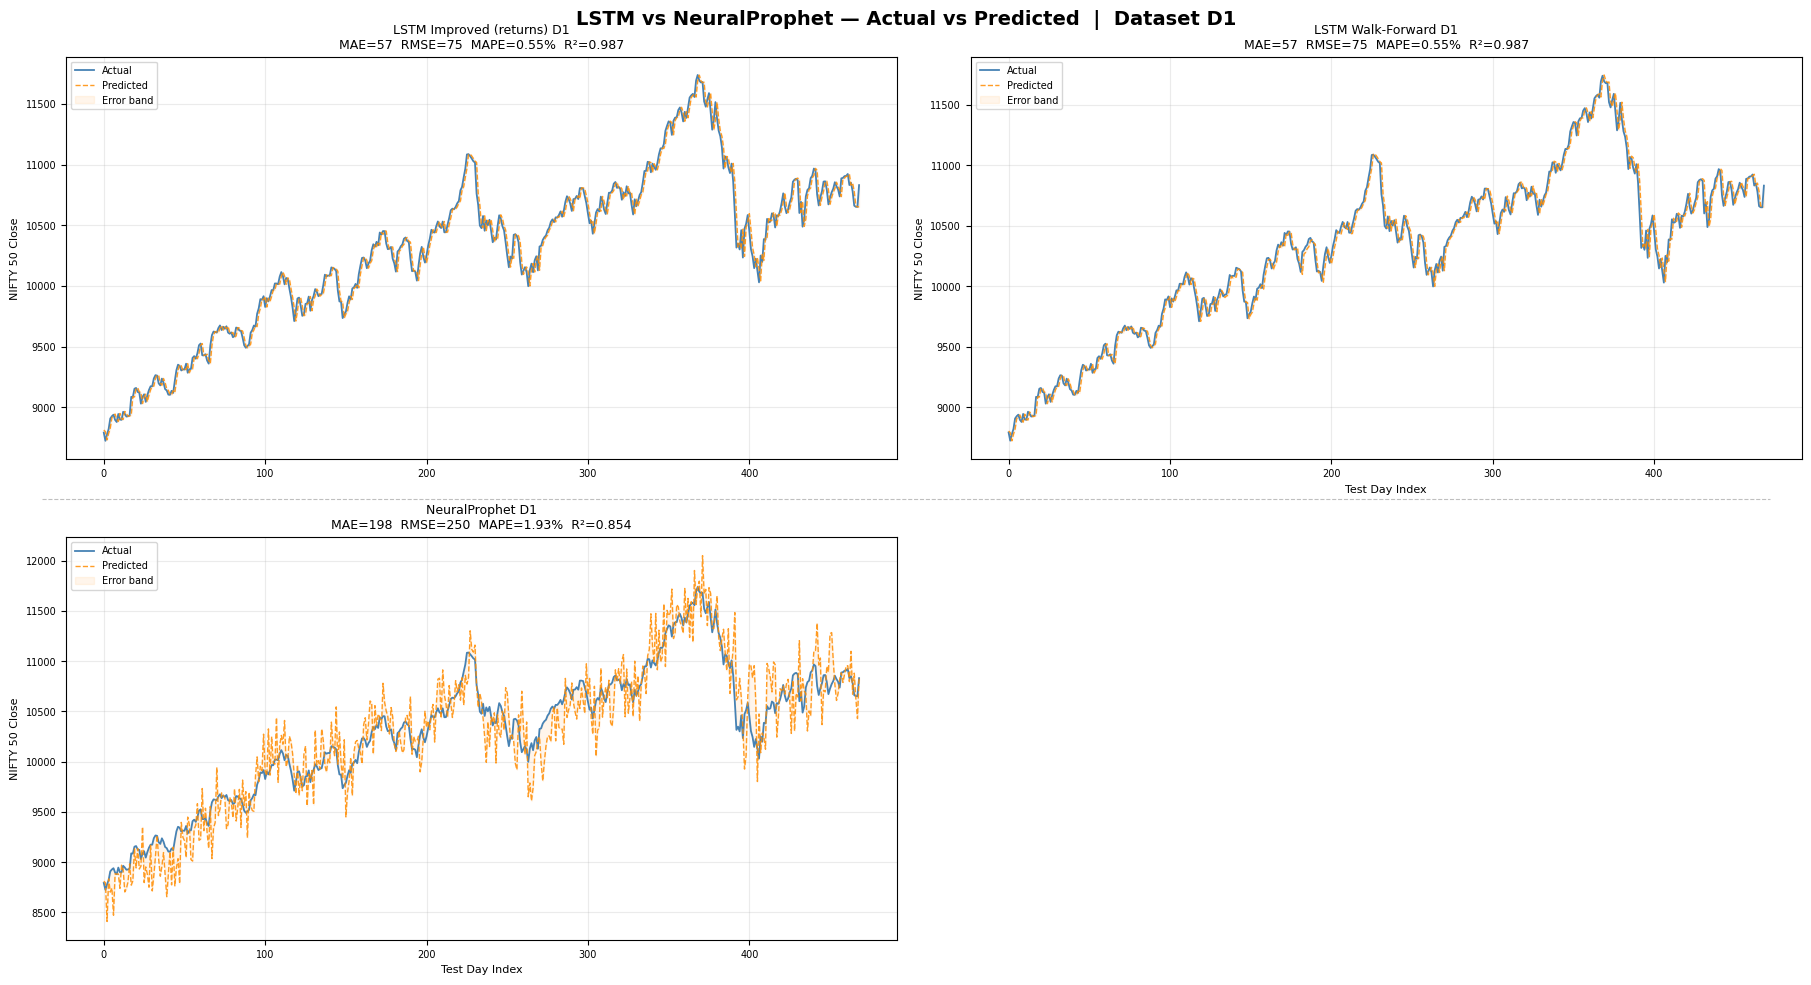

✅ D1 figure saved → /content/drive/MyDrive/NIFTY50_Forecast/data/lstm_vs_np_D1.png


In [37]:
# ── CELL: Figure 1 — Dataset D1 (LSTM + NeuralProphet) ───────────────────

# Keys to plot — edit this list to match your results dict keys exactly
lstm_keys_d1 = [
    'lstm_imp_D1',     # Improved LSTM single-shot
    'lstm_wf_D1',      # LSTM walk-forward
]
np_keys_d1 = [
    'np_D1',           # NeuralProphet single-shot
    'np_wf_D1',        # NeuralProphet walk-forward
]

plot_keys_d1 = lstm_keys_d1 + np_keys_d1
# Filter to only keys that exist in results
plot_keys_d1 = [k for k in plot_keys_d1 if k in results]

n      = len(plot_keys_d1)
n_cols = 2
n_rows = (n + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, n_rows * 4.8),
                         constrained_layout=True)
axes = axes.flatten()

for i, (ax, key) in enumerate(zip(axes, plot_keys_d1)):
    show_x = (i >= n - n_cols)          # only bottom row gets x-label
    plot_model_panel(ax, results[key], show_xlabel=show_x)

# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

# Divider line between LSTM and NeuralProphet rows
if len(lstm_keys_d1) % n_cols == 0:
    divider_row = len(lstm_keys_d1) // n_cols
    fig.add_artist(
        plt.Line2D(
            [0.02, 0.98],
            [1 - divider_row / n_rows, 1 - divider_row / n_rows],
            transform=fig.transFigure,
            color='grey', lw=0.8, linestyle='--', alpha=0.5
        )
    )

fig.suptitle(
    'LSTM vs NeuralProphet — Actual vs Predicted  |  Dataset D1',
    fontsize=14, fontweight='bold', y=1.01
)

path_d1 = os.path.join(DATA_DIR, 'lstm_vs_np_D1.png')
plt.savefig(path_d1, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ D1 figure saved → {path_d1}")

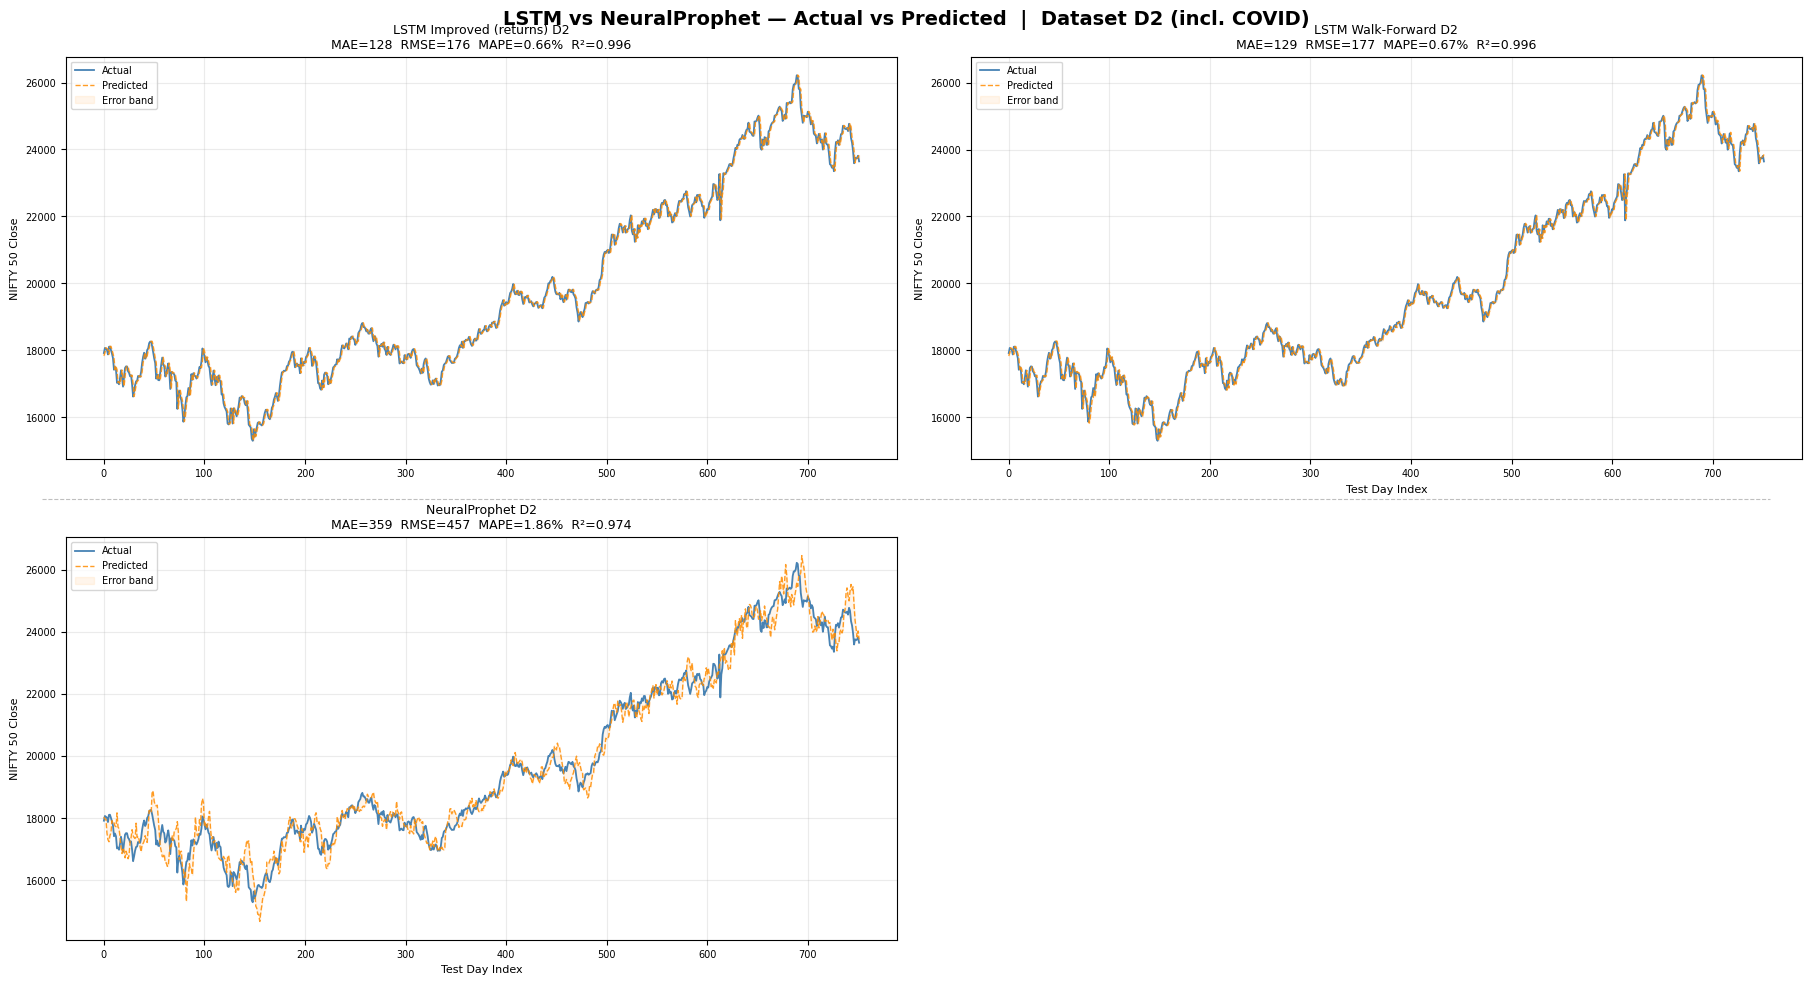

✅ D2 figure saved → /content/drive/MyDrive/NIFTY50_Forecast/data/lstm_vs_np_D2.png


In [38]:
# ── CELL: Figure 2 — Dataset D2 (LSTM + NeuralProphet) ───────────────────

lstm_keys_d2 = [
    'lstm_imp_D2',
    'lstm_wf_D2',
]
np_keys_d2 = [
    'np_D2',
    'np_wf_D2',
]

plot_keys_d2 = lstm_keys_d2 + np_keys_d2
plot_keys_d2 = [k for k in plot_keys_d2 if k in results]

n      = len(plot_keys_d2)
n_cols = 2
n_rows = (n + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, n_rows * 4.8),
                         constrained_layout=True)
axes = axes.flatten()

for i, (ax, key) in enumerate(zip(axes, plot_keys_d2)):
    show_x = (i >= n - n_cols)
    plot_model_panel(ax, results[key], show_xlabel=show_x)

for ax in axes[n:]:
    ax.set_visible(False)

if len(lstm_keys_d2) % n_cols == 0:
    divider_row = len(lstm_keys_d2) // n_cols
    fig.add_artist(
        plt.Line2D(
            [0.02, 0.98],
            [1 - divider_row / n_rows, 1 - divider_row / n_rows],
            transform=fig.transFigure,
            color='grey', lw=0.8, linestyle='--', alpha=0.5
        )
    )

fig.suptitle(
    'LSTM vs NeuralProphet — Actual vs Predicted  |  Dataset D2 (incl. COVID)',
    fontsize=14, fontweight='bold', y=1.01
)

path_d2 = os.path.join(DATA_DIR, 'lstm_vs_np_D2.png')
plt.savefig(path_d2, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ D2 figure saved → {path_d2}")

# misc

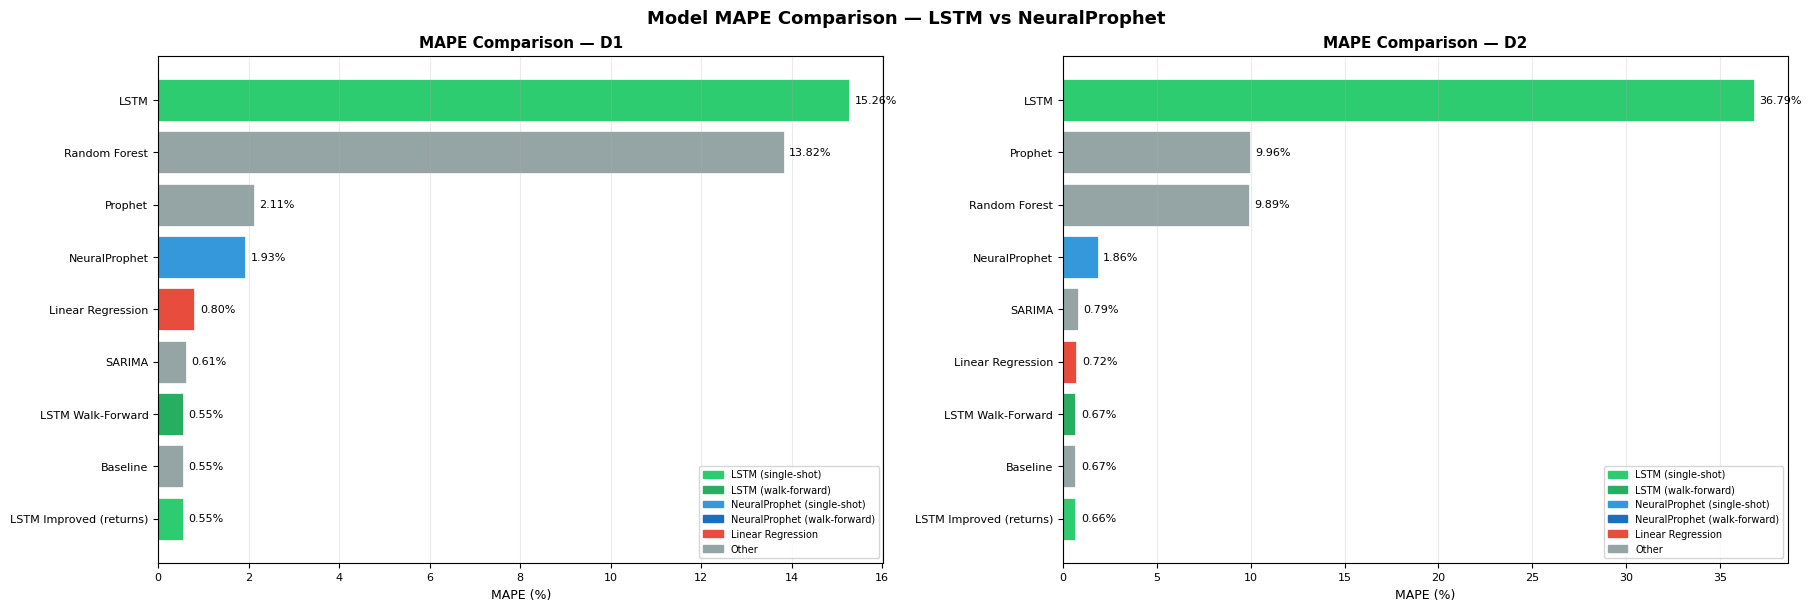

✅ MAPE bar chart saved → /content/drive/MyDrive/NIFTY50_Forecast/data/mape_lstm_vs_np.png


In [39]:
# ── CELL: Figure 3 — Side-by-side MAPE bar chart (all models, D1 & D2) ───

from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

for ax, tag in zip(axes, ['D1', 'D2']):
    keys = [k for k in results if k.endswith(tag)]
    if not keys:
        ax.set_visible(False)
        continue

    sub = pd.DataFrame([
        {'Model': results[k]['label'], 'MAPE': results[k]['MAPE']}
        for k in keys
    ]).sort_values('MAPE', ascending=True)

    # Colour by model family
    def bar_color(name):
        if 'Walk-Forward' in name and 'LSTM' in name:   return '#27ae60'
        if 'LSTM' in name:                               return '#2ecc71'
        if 'Walk-Forward' in name and 'Neural' in name: return '#1a6fbf'
        if 'Neural' in name:                             return '#3498db'
        if 'Regression' in name:                        return '#e74c3c'
        return '#95a5a6'

    colors = [bar_color(m) for m in sub['Model']]

    # Strip dataset tag from label for cleaner display
    labels = sub['Model'].str.replace(f' {tag}', '', regex=False)

    bars = ax.barh(labels, sub['MAPE'], color=colors, edgecolor='white',
                   linewidth=0.5)
    ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=8)
    ax.set_xlabel('MAPE (%)', fontsize=9)
    ax.set_title(f'MAPE Comparison — {tag}', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.25)
    ax.tick_params(labelsize=8)

    legend_handles = [
        Patch(color='#2ecc71',  label='LSTM (single-shot)'),
        Patch(color='#27ae60',  label='LSTM (walk-forward)'),
        Patch(color='#3498db',  label='NeuralProphet (single-shot)'),
        Patch(color='#1a6fbf',  label='NeuralProphet (walk-forward)'),
        Patch(color='#e74c3c',  label='Linear Regression'),
        Patch(color='#95a5a6',  label='Other'),
    ]
    ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

fig.suptitle('Model MAPE Comparison — LSTM vs NeuralProphet',
             fontsize=13, fontweight='bold')

path_bar = os.path.join(DATA_DIR, 'mape_lstm_vs_np.png')
plt.savefig(path_bar, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ MAPE bar chart saved → {path_bar}")

# confusion matrix viz


 CONFUSION MATRIX VISUALIZATIONS


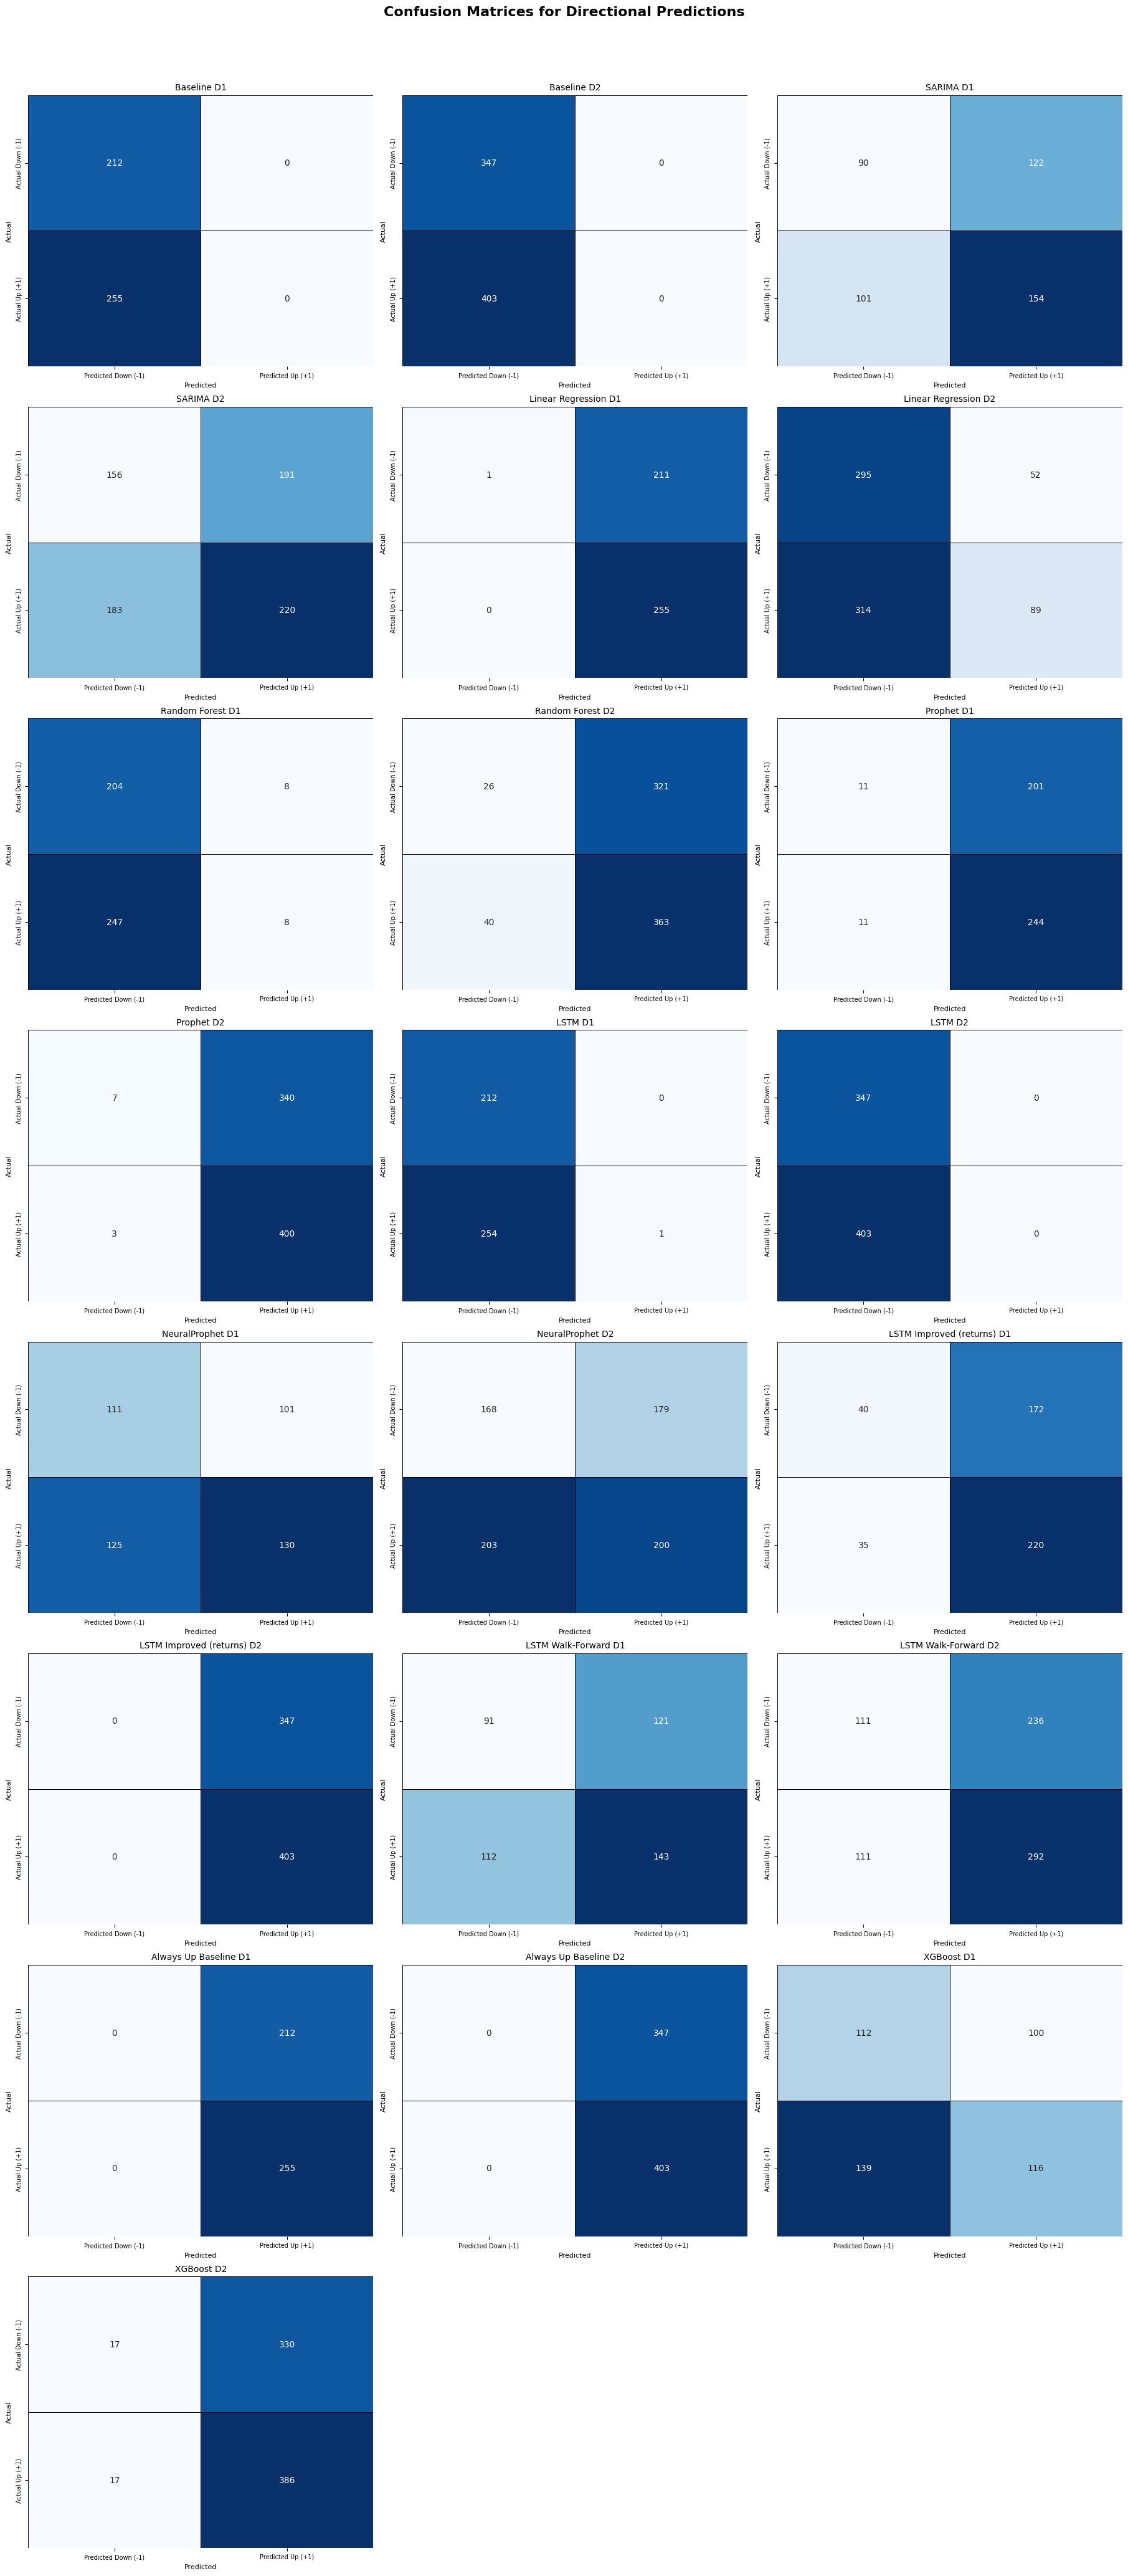

✅ Confusion matrices saved to /content/drive/MyDrive/NIFTY50_Forecast/data/confusion_matrices.png


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

print("\n" + "=" * 70)
print(" CONFUSION MATRIX VISUALIZATIONS")
print("=" * 70)

LABELS = [-1, 1] # -1 for Down, 1 for Up

n_models = len(results)
n_cols_per_row = 3
n_rows = (n_models + n_cols_per_row - 1) // n_cols_per_row # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(n_cols_per_row * 6, n_rows * 5), constrained_layout=True)
axes = axes.flatten()

for idx, (key, r) in enumerate(results.items()):
    if idx >= len(axes): # Avoid error if there are more models than subplots initially planned
        break

    ax = axes[idx]

    if 'y_true' not in r or 'y_pred' not in r:
        ax.set_title(f"Skipping {r.get('label', key)}\n(Missing data)")
        ax.set_visible(False)
        continue

    y_true = np.array(r['y_true'])
    y_pred = np.array(r['y_pred'])

    # Calculate actual and predicted directions, similar to directional_accuracy
    actual_dir_raw = np.sign(y_true[1:] - y_true[:-1])
    pred_dir_raw   = np.sign(y_pred[1:] - y_true[:-1])

    # Filter out zero changes from actual movements to focus on clear up/down classifications
    non_zero_mask = (actual_dir_raw != 0)
    actual_dir = actual_dir_raw[non_zero_mask]
    pred_dir   = pred_dir_raw[non_zero_mask]

    # Treat predicted 'no change' (0) as 'down' (-1) for binary classification
    pred_dir_processed = np.where(pred_dir == 0, -1, pred_dir)

    if len(actual_dir) > 0 and len(pred_dir_processed) > 0:
        cm = confusion_matrix(actual_dir, pred_dir_processed, labels=LABELS)
        cm_df = pd.DataFrame(cm, index=['Actual Down (-1)', 'Actual Up (+1)'], columns=['Predicted Down (-1)', 'Predicted Up (+1)'])

        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.5, linecolor='black', ax=ax)
        ax.set_title(f"{r['label']}", fontsize=10)
        ax.set_ylabel('Actual', fontsize=8)
        ax.set_xlabel('Predicted', fontsize=8)
        ax.tick_params(axis='both', which='major', labelsize=7)
    else:
        ax.set_title(f"{r['label']}\n(Not enough data)", fontsize=10)
        ax.set_visible(False)

# Hide any unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Confusion Matrices for Directional Predictions', fontsize=16, fontweight='bold', y=1.03)

output_path = os.path.join(DATA_DIR, 'confusion_matrices.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrices saved to {output_path}")
print("=" * 70)

# FINAL RESULTS

In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL CELL A: Results Summary Table
# ══════════════════════════════════════════════════════════════════════════════
# Collects every entry in `results`, splits into D1/D2, ranks by MAPE.
# Highlights the best model per dataset in green. Saves CSV to DATA_DIR.

import pandas as pd
import numpy as np

# ── Ordered model display names (edit to match your actual result keys) ──
MODEL_ORDER = [
    'baseline_D1',   'baseline_D2',
    'sarima_D1',     'sarima_D2',
    'mr_D1',         'mr_D2',
    'rf_D1',         'rf_D2',
    'prophet_D1',    'prophet_D2',
    'lstm_D1',       'lstm_D2',
    'lstm_imp_D1',   'lstm_imp_D2',
    'lstm_wf_D1',    'lstm_wf_D2',
    'np_D1',         'np_D2',
    'np_wf_D1',      'np_wf_D2',
    'xgb_D1',        'xgb_D2',
]

def build_summary(results_dict, model_order):
    rows = []
    for key in model_order:
        if key not in results_dict:
            continue
        r = results_dict[key]
        dataset = 'D1 (Pre-COVID)' if key.endswith('_D1') else 'D2 (Full)'
        rows.append({
            'Dataset'  : dataset,
            'Model'    : r['label'],
            'RMSE'     : round(r['RMSE'], 1),
            'MAE'      : round(r['MAE'],  1),
            'MAPE (%)'  : round(r['MAPE'], 3),
            'R²'       : round(r['R2'],   4),
        })
    # Also catch any keys not in ORDER list (e.g. new additions)
    for key, r in results_dict.items():
        if key not in model_order:
            dataset = 'D1 (Pre-COVID)' if 'D1' in key else 'D2 (Full)'
            rows.append({
                'Dataset'  : dataset,
                'Model'    : r['label'],
                'RMSE'     : round(r['RMSE'], 1),
                'MAE'      : round(r['MAE'],  1),
                'MAPE (%)'  : round(r['MAPE'], 3),
                'R²'       : round(r['R2'],   4),
            })
    df = pd.DataFrame(rows)
    return df

summary_df = build_summary(results, MODEL_ORDER)

# ── Pretty-print with rank within each dataset ──
print("\n" + "="*90)
print("  NIFTY 50 FORECASTING — FULL MODEL COMPARISON")
print("="*90)

for dataset_label in ['D1 (Pre-COVID)', 'D2 (Full)']:
    sub = summary_df[summary_df['Dataset'] == dataset_label].copy()
    sub = sub.sort_values('MAPE (%)').reset_index(drop=True)
    sub.index += 1
    sub.index.name = 'Rank'
    print(f"\n{'─'*90}")
    print(f"  {dataset_label}")
    print(f"{'─'*90}")
    print(sub[['Model','RMSE','MAE','MAPE (%)','R²']].to_string())

print("\n" + "="*90)

# ── Save CSV ──
out_path = os.path.join(DATA_DIR, 'model_comparison_FINAL.csv')
summary_df.sort_values(['Dataset','MAPE (%)']).to_csv(out_path, index=False)
print(f"\n✅ Table saved → {out_path}")


  NIFTY 50 FORECASTING — FULL MODEL COMPARISON

──────────────────────────────────────────────────────────────────────────────────────────
  D1 (Pre-COVID)
──────────────────────────────────────────────────────────────────────────────────────────
                           Model    RMSE     MAE  MAPE (%)      R²
Rank                                                              
1          Always Up Baseline D1    75.0    56.5     0.546  0.9868
2                    Baseline D1    74.8    56.7     0.548  0.9869
3     LSTM Improved (returns) D1    74.8    56.6     0.548  0.9869
4           LSTM Walk-Forward D1    75.2    56.9     0.550  0.9868
5                     XGBoost D1    75.3    57.1     0.552  0.9867
6               Random Forest D1    79.7    63.1     0.609  0.9851
7                      SARIMA D1    84.5    63.6     0.615  0.9833
8                     Prophet D1    98.6    72.4     0.695  0.9773
9           Linear Regression D1   102.0    82.9     0.803  0.9757
10             

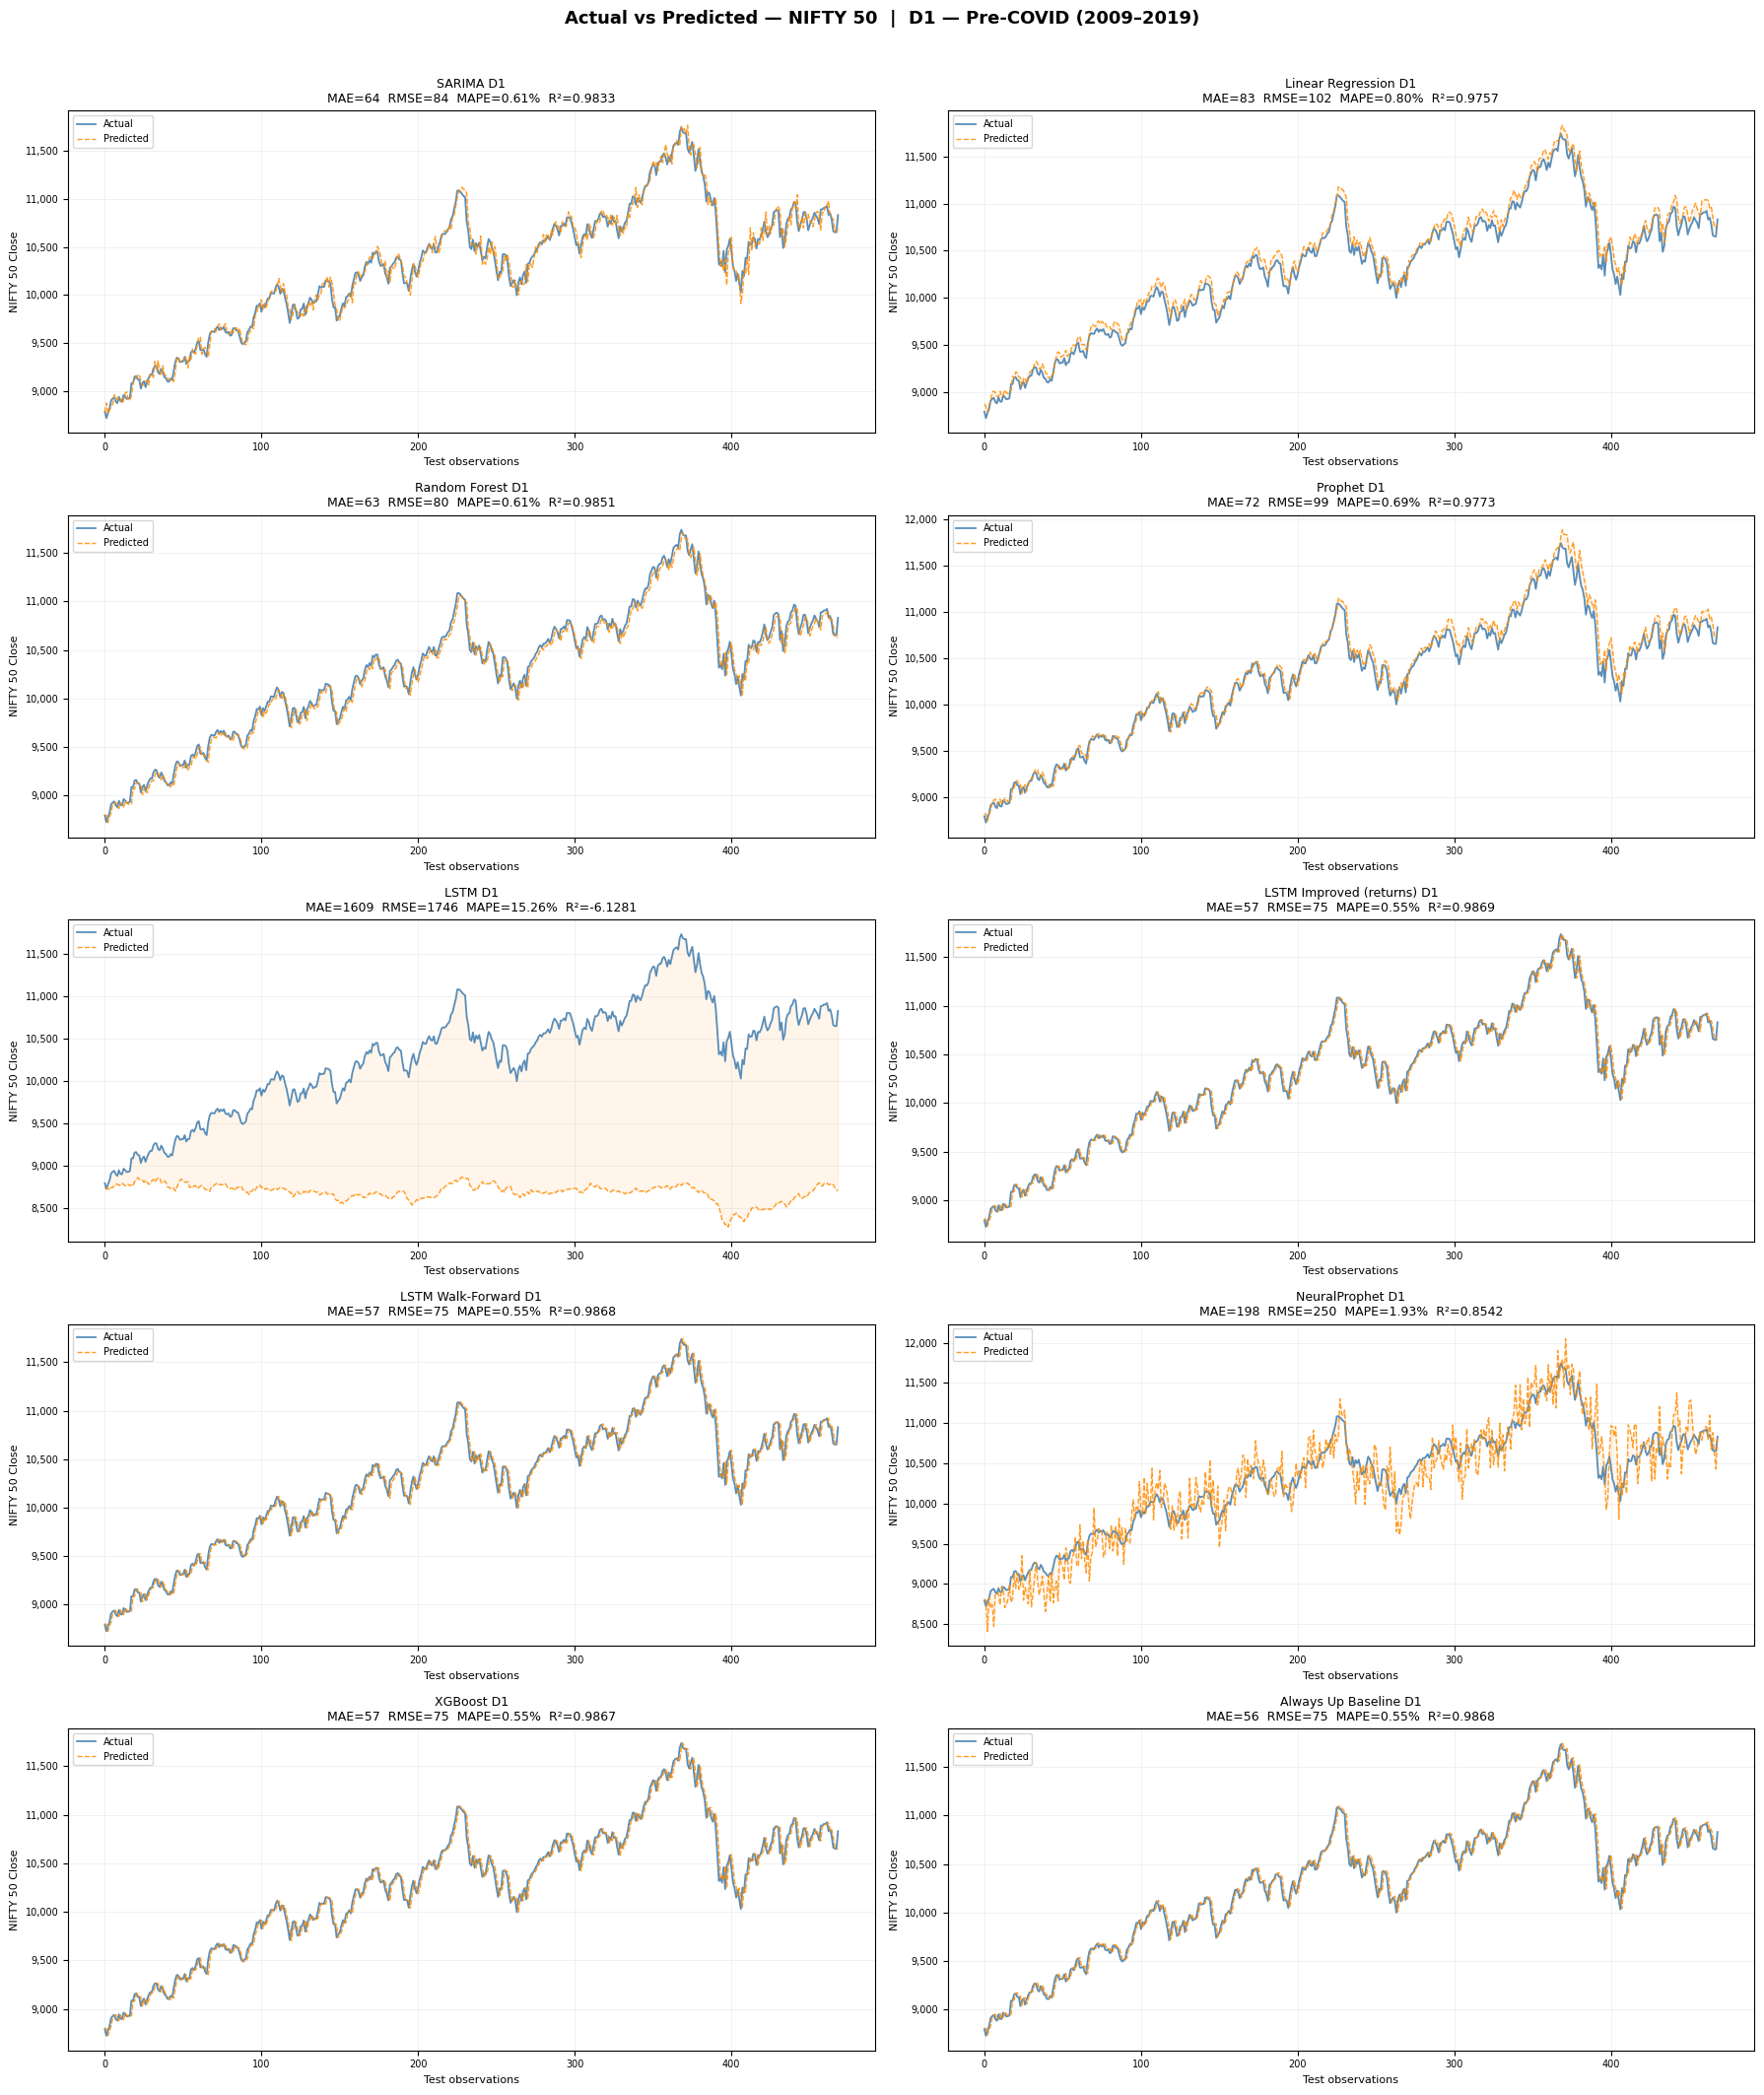

✅ Saved → /content/drive/MyDrive/NIFTY50_Forecast/data/final_actual_vs_pred_D1.png


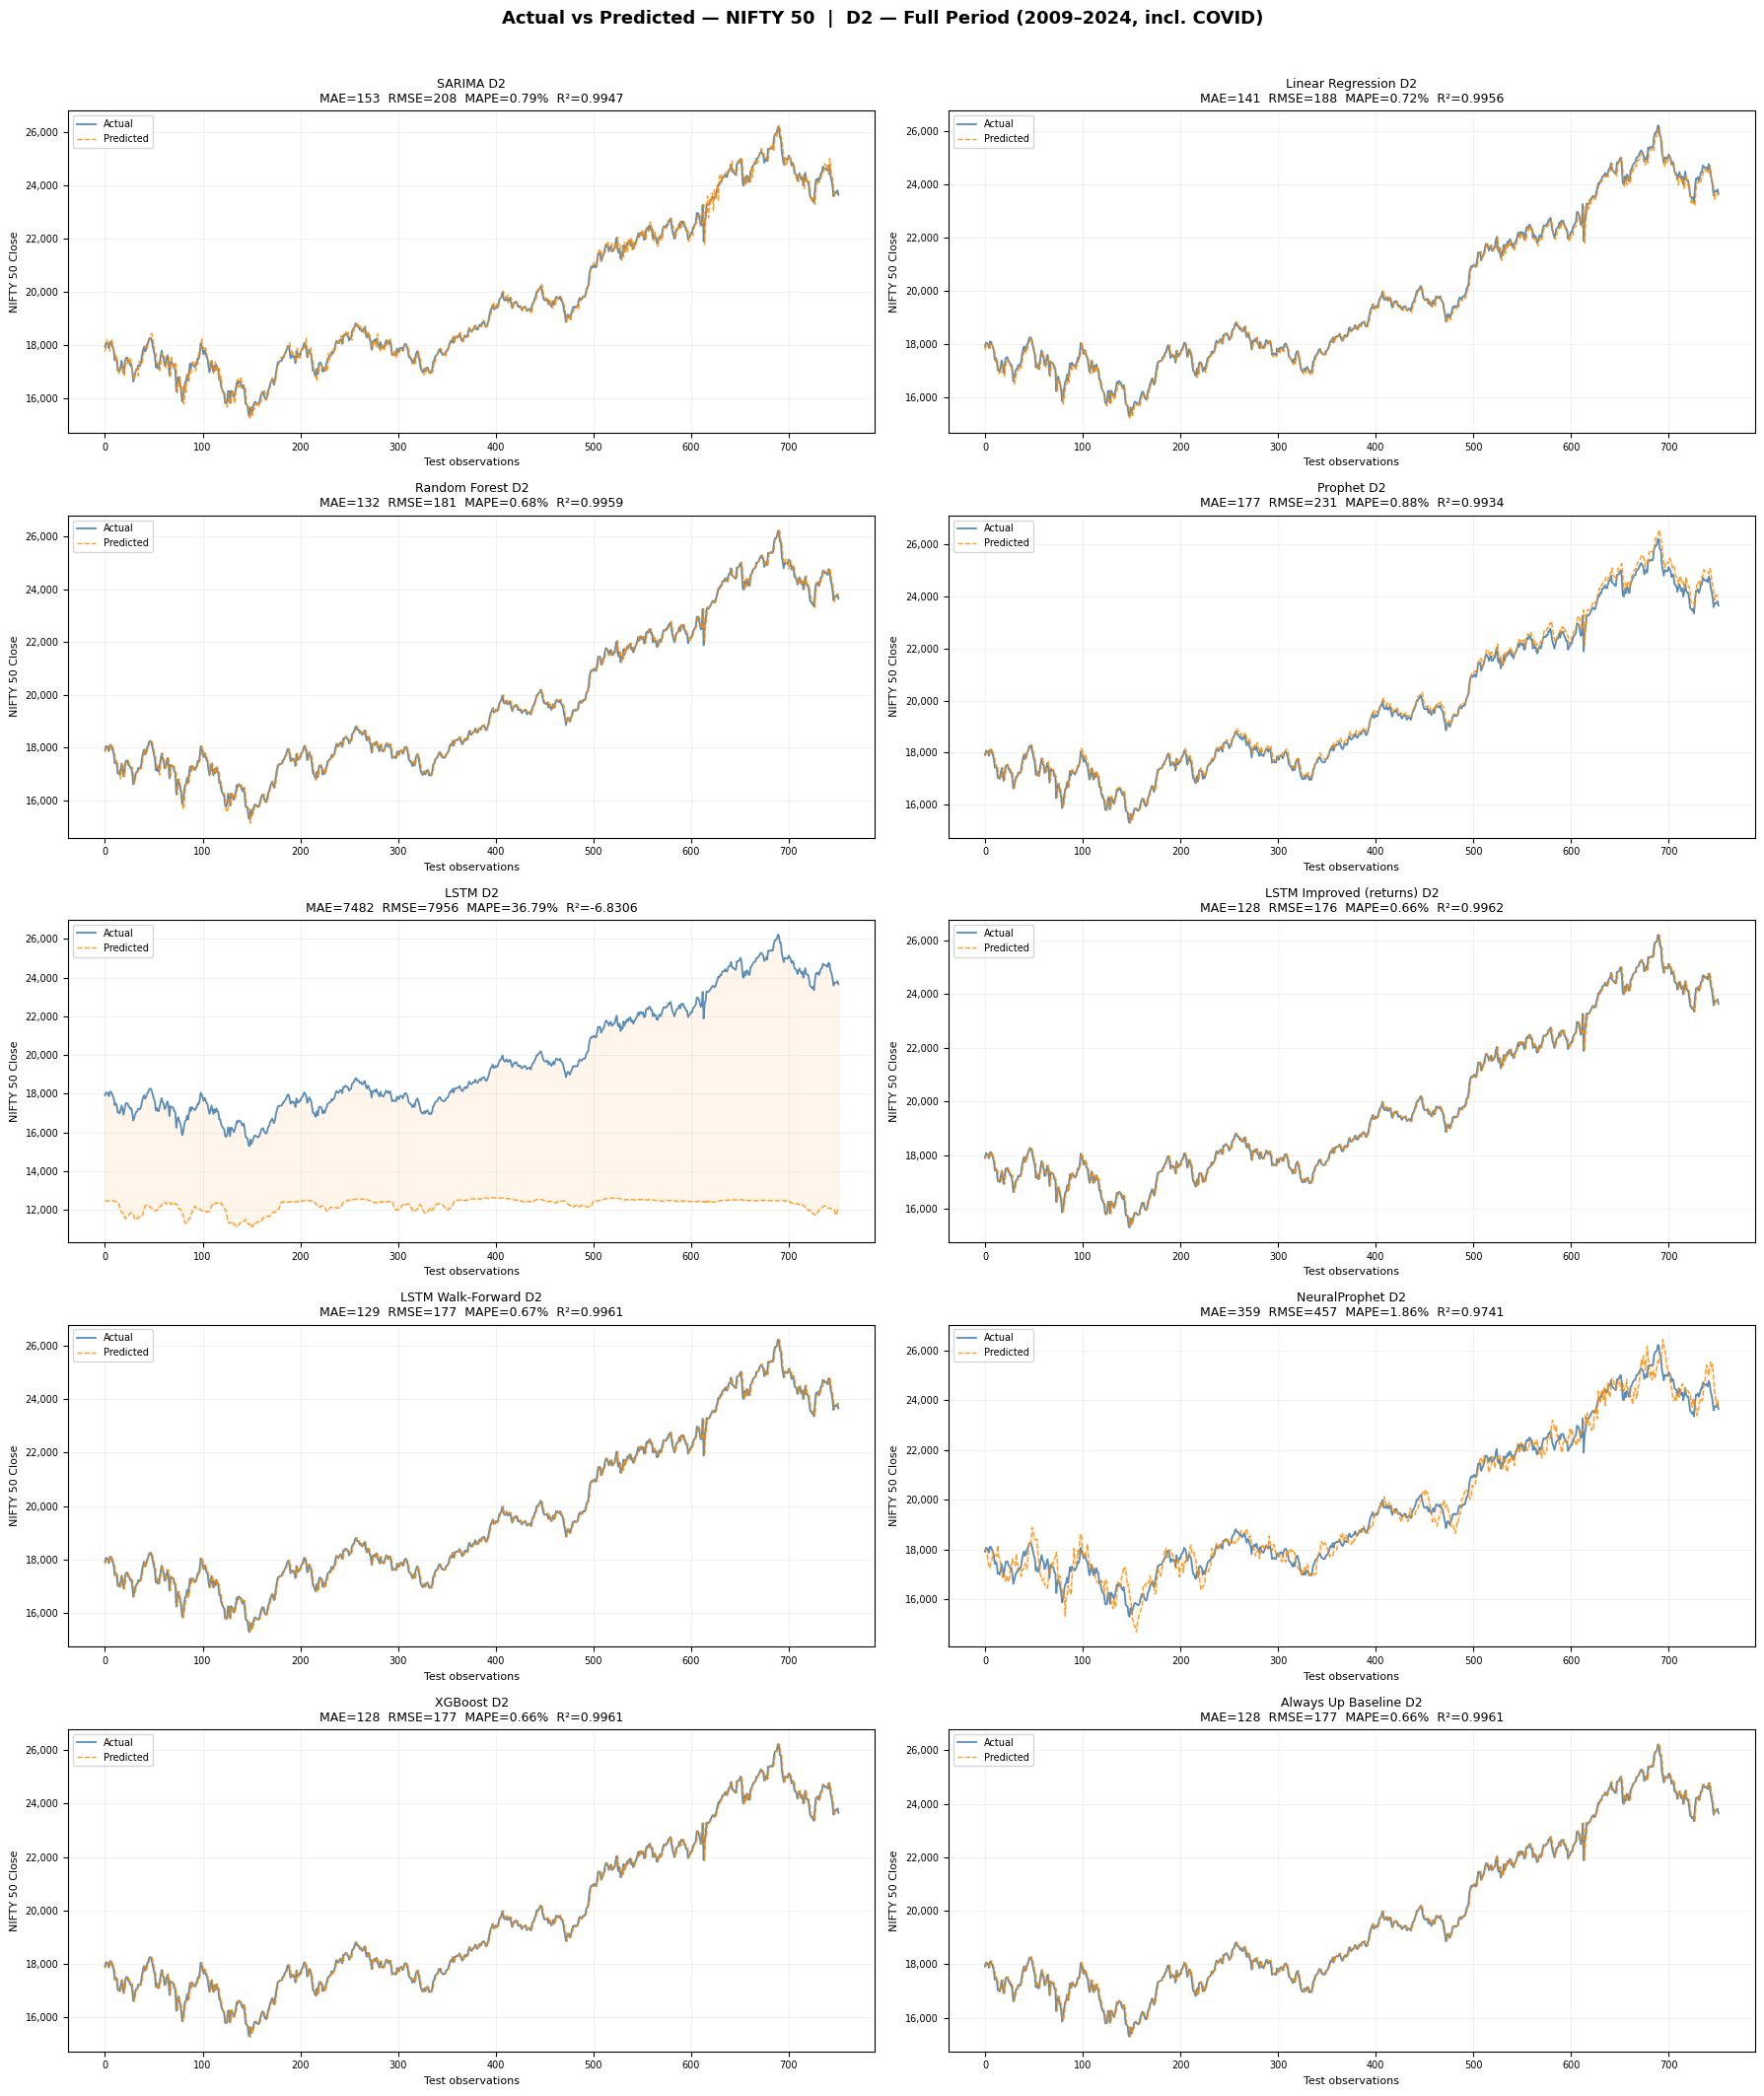

✅ Saved → /content/drive/MyDrive/NIFTY50_Forecast/data/final_actual_vs_pred_D2.png


In [58]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL CELL B: Actual vs Predicted — All Models, Both Datasets
# ══════════════════════════════════════════════════════════════════════════════
# One panel per model per dataset. Actual in blue, predicted in orange dashed.
# Metrics shown in title. Baseline excluded (it just repeats price).
# Saves two figures: one per dataset.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PLOT_ORDER_D1 = [k for k in MODEL_ORDER if k.endswith('_D1') and not k.startswith('baseline') and k in results]
PLOT_ORDER_D2 = [k for k in MODEL_ORDER if k.endswith('_D2') and not k.startswith('baseline') and k in results]
# catch any extra keys not in MODEL_ORDER
for k in results:
    if k.endswith('_D1') and not k.startswith('baseline') and k not in PLOT_ORDER_D1:
        PLOT_ORDER_D1.append(k)
    if k.endswith('_D2') and not k.startswith('baseline') and k not in PLOT_ORDER_D2:
        PLOT_ORDER_D2.append(k)

def plot_actual_vs_predicted(keys, dataset_title, save_name):
    n = len(keys)
    if n == 0:
        print(f"No results found for {dataset_title}"); return

    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4.2))
    axes = axes.flatten()

    for idx, key in enumerate(keys):
        ax  = axes[idx]
        r   = results[key]
        yt  = r['y_true']
        yp  = r['y_pred']
        n_pts = len(yt)

        ax.plot(yt, label='Actual',    color='steelblue',   linewidth=1.3, alpha=0.9)
        ax.plot(yp, label='Predicted', color='darkorange',  linewidth=1.0,
                linestyle='--', alpha=0.85)

        # Shade error
        ax.fill_between(range(n_pts), yt, yp,
                        alpha=0.08, color='darkorange')

        ax.set_title(
            f"{r['label']}\n"
            f"MAE={r['MAE']:.0f}  RMSE={r['RMSE']:.0f}  "
            f"MAPE={r['MAPE']:.2f}%  R²={r['R2']:.4f}",
            fontsize=9, pad=6
        )
        ax.set_ylabel('NIFTY 50 Close', fontsize=8)
        ax.set_xlabel('Test observations', fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'{x:,.0f}'))
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.tick_params(labelsize=7)

    # Hide unused panels
    for idx in range(len(keys), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f'Actual vs Predicted — NIFTY 50  |  {dataset_title}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    save_path = os.path.join(DATA_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save_path}")

plot_actual_vs_predicted(PLOT_ORDER_D1,
                         dataset_title='D1 — Pre-COVID (2009–2019)',
                         save_name='final_actual_vs_pred_D1.png')

plot_actual_vs_predicted(PLOT_ORDER_D2,
                         dataset_title='D2 — Full Period (2009–2024, incl. COVID)',
                         save_name='final_actual_vs_pred_D2.png')


  DIRECTIONAL ACCURACY — ALL MODELS

──────────────────────────────────────────────────────────────────────
  D1 — Pre-COVID
──────────────────────────────────────────────────────────────────────
  Model                                           Directional Accuracy
  ────────────────────────────────────────────  ────────────────────
  Linear Regression D1                            58.55%  █████████████████████████████
  Random Forest D1                                54.06%  ███████████████████████████
  LSTM Improved (returns) D1                      53.85%  ██████████████████████████
  Always Up Baseline D1                           53.85%  ██████████████████████████
  LSTM Walk-Forward D1                            53.63%  ██████████████████████████
  XGBoost D1                                      53.42%  ██████████████████████████
  Prophet D1                                      52.78%  ██████████████████████████
  SARIMA D1                                       52.56%  ██████

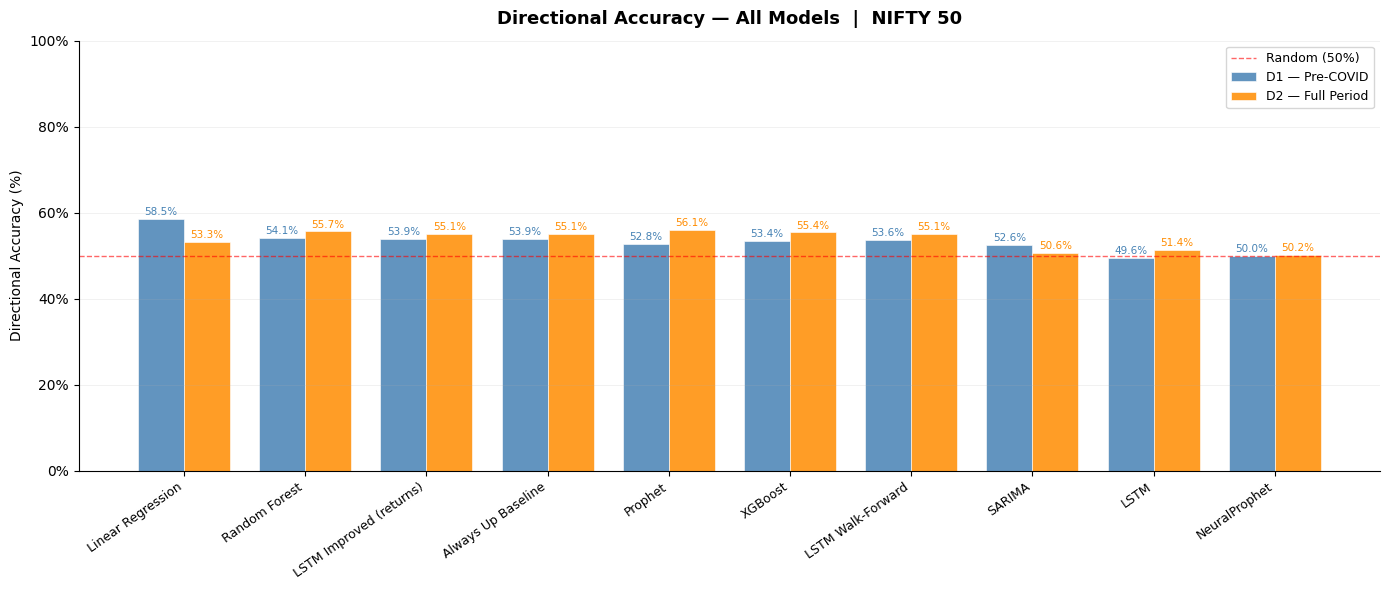

✅ Bar chart saved → /content/drive/MyDrive/NIFTY50_Forecast/data/directional_accuracy_barchart.png


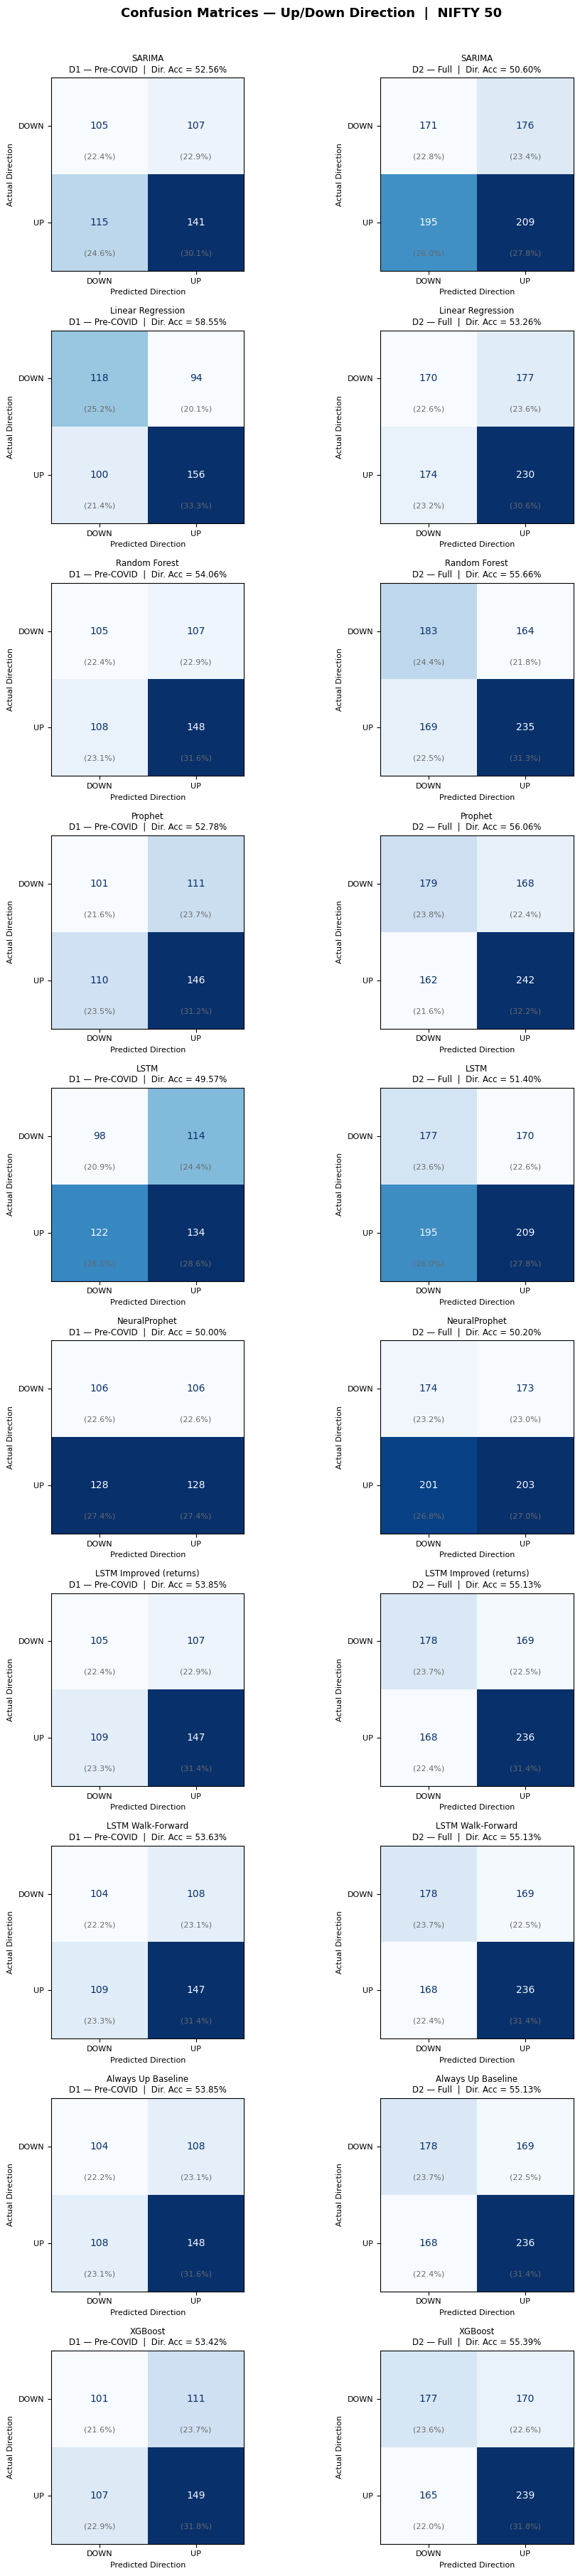

✅ Confusion matrices saved → /content/drive/MyDrive/NIFTY50_Forecast/data/confusion_matrices_all_models.png


In [59]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL CELL C: Directional Accuracy + Bar Chart + Confusion Matrices
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Helper: compute directional accuracy for one result entry ─────────────────
def directional_accuracy(y_true, y_pred):
    """
    Up/down direction hit rate.
    Direction is defined as: today's price vs yesterday's price.
    We align true vs pred on the same day, so both use the same prev price.
    Returns: accuracy (0–100), true_dir array, pred_dir array
    """
    true_dir = np.sign(np.diff(y_true))   # +1 up, -1 down, 0 flat
    pred_dir = np.sign(np.diff(y_pred))
    # treat flat (0) as up to avoid ambiguity
    true_dir[true_dir == 0] = 1
    pred_dir[pred_dir == 0] = 1
    acc = np.mean(true_dir == pred_dir) * 100
    return acc, true_dir, pred_dir

# ── Step 1: Compute directional accuracy for every model ─────────────────────
dir_results = {}
skip_keys = [k for k in results if k.startswith('baseline')]

for key, r in results.items():
    if key in skip_keys:
        continue
    acc, td, pd_ = directional_accuracy(r['y_true'], r['y_pred'])
    dir_results[key] = {
        'label'    : r['label'],
        'accuracy' : round(acc, 2),
        'true_dir' : td,
        'pred_dir' : pd_,
        'dataset'  : 'D1' if key.endswith('_D1') else 'D2',
    }

# ── Step 2: Print summary table ───────────────────────────────────────────────
print("\n" + "="*70)
print("  DIRECTIONAL ACCURACY — ALL MODELS")
print("="*70)

for ds_label, ds_tag in [('D1 — Pre-COVID', 'D1'), ('D2 — Full Period', 'D2')]:
    sub = {k: v for k, v in dir_results.items() if v['dataset'] == ds_tag}
    sub_sorted = sorted(sub.items(), key=lambda x: -x[1]['accuracy'])
    print(f"\n{'─'*70}")
    print(f"  {ds_label}")
    print(f"{'─'*70}")
    print(f"  {'Model':<46s}  Directional Accuracy")
    print(f"  {'─'*44}  {'─'*20}")
    for key, v in sub_sorted:
        bar = '█' * int(v['accuracy'] / 2)   # visual bar in terminal
        print(f"  {v['label']:<46s}  {v['accuracy']:5.2f}%  {bar}")

print("\n" + "="*70)

# ── Step 3: Bar Chart — Directional Accuracy, D1 vs D2 side by side ──────────
# Pair models: find keys present in both D1 and D2
base_keys = set(k.replace('_D1','').replace('_D2','') for k in dir_results)
paired = []
for bk in base_keys:
    k1, k2 = bk + '_D1', bk + '_D2'
    if k1 in dir_results and k2 in dir_results:
        paired.append((bk, dir_results[k1], dir_results[k2]))
    elif k1 in dir_results:
        paired.append((bk, dir_results[k1], None))
    elif k2 in dir_results:
        paired.append((bk, None, dir_results[k2]))

# Sort by average accuracy descending
def avg_acc(p):
    vals = [x['accuracy'] for x in [p[1], p[2]] if x is not None]
    return np.mean(vals)
paired.sort(key=avg_acc, reverse=True)

model_labels = [p[1]['label'].replace(' D1','').replace(' D2','') if p[1] else
                p[2]['label'].replace(' D1','').replace(' D2','') for p in paired]
acc_d1 = [p[1]['accuracy'] if p[1] else 0 for p in paired]
acc_d2 = [p[2]['accuracy'] if p[2] else 0 for p in paired]

x      = np.arange(len(paired))
width  = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, acc_d1, width, label='D1 — Pre-COVID',
               color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, acc_d2, width, label='D2 — Full Period',
               color='darkorange', alpha=0.85, edgecolor='white', linewidth=0.5)

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5, color='steelblue')
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5, color='darkorange')

ax.axhline(50, color='red', linestyle='--', linewidth=1.0, alpha=0.6, label='Random (50%)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Directional Accuracy (%)', fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('Directional Accuracy — All Models  |  NIFTY 50',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.grid(axis='y', alpha=0.25, linewidth=0.5)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
bar_path = os.path.join(DATA_DIR, 'directional_accuracy_barchart.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Bar chart saved → {bar_path}")

# ── Step 4: Confusion Matrices — one per model per dataset ───────────────────
# Laid out in a grid: rows = models, cols = D1 | D2
# Label mapping: -1 → DOWN, +1 → UP

LABEL_NAMES = ['DOWN', 'UP']
LABEL_VALUES = [-1, 1]

# Collect models that have both D1 and D2 for a clean paired grid
# Models with only one dataset get their own row
all_cm_keys_d1 = [k for k in dir_results if dir_results[k]['dataset'] == 'D1']
all_cm_keys_d2 = [k for k in dir_results if dir_results[k]['dataset'] == 'D2']

# Build ordered list of base model keys to plot
cm_base_keys = []
seen = set()
for k in list(all_cm_keys_d1) + list(all_cm_keys_d2):
    bk = k.replace('_D1','').replace('_D2','')
    if bk not in seen:
        cm_base_keys.append(bk)
        seen.add(bk)

n_models = len(cm_base_keys)
fig, axes = plt.subplots(n_models, 2,
                          figsize=(10, n_models * 3.6))
if n_models == 1:
    axes = axes.reshape(1, 2)

for row_idx, bk in enumerate(cm_base_keys):
    for col_idx, (ds_tag, ds_label) in enumerate([('D1','D1 — Pre-COVID'),
                                                   ('D2','D2 — Full')]):
        ax  = axes[row_idx, col_idx]
        key = bk + f'_{ds_tag}'

        if key not in dir_results:
            ax.set_visible(False)
            continue

        v  = dir_results[key]
        cm = confusion_matrix(v['true_dir'], v['pred_dir'], labels=LABEL_VALUES)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=LABEL_NAMES)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')

        # Annotate cells with % of total
        total = cm.sum()
        for i in range(2):
            for j in range(2):
                pct = cm[i, j] / total * 100
                ax.text(j, i + 0.32, f'({pct:.1f}%)',
                        ha='center', va='center',
                        fontsize=8, color='dimgray')

        model_name = v['label'].replace(' D1','').replace(' D2','')
        ax.set_title(f"{model_name}\n{ds_label}  |  Dir. Acc = {v['accuracy']:.2f}%",
                     fontsize=8.5, pad=6)
        ax.set_xlabel('Predicted Direction', fontsize=8)
        ax.set_ylabel('Actual Direction',    fontsize=8)
        ax.tick_params(labelsize=8)

fig.suptitle('Confusion Matrices — Up/Down Direction  |  NIFTY 50',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
cm_path = os.path.join(DATA_DIR, 'confusion_matrices_all_models.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Confusion matrices saved → {cm_path}")